#  MGB analysis

## Functions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.utils import concordance_index
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test
import warnings
warnings.filterwarnings('ignore')

mpl.rcParams.update(mpl.rcParamsDefault)

sns.reset_orig()

import matplotlib.patheffects as pe

#################################################################################### Association analysis
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

def run_logit_with_units_and_refs(
    df,
    outcome: str,
    continuous_units: dict,     # {"Age": 10, "BMI": 5}
    categorical_refs: dict,     # {"Sex": "F", "Race": "White", "group": "Negative"}
    drop_na=True,
    print_counts=True,
    compute_auc=True
):
    import numpy as np
    import pandas as pd
    import statsmodels.formula.api as smf
    from sklearn.metrics import roc_auc_score

    data = df.copy()
    data[outcome] = pd.to_numeric(data[outcome], errors='coerce')

    # 1) continuous scaling(per unit)
    cont_terms_formula = []
    cont_terms_data = []
    pretty_cont_labels = {}
    for var, unit in continuous_units.items():
        data[var] = pd.to_numeric(data[var], errors='coerce')
        scaled = f"{var}_per_{unit}"
        data[scaled] = data[var] / float(unit)
        cont_terms_formula.append(f'Q("{scaled}")')
        cont_terms_data.append(scaled)
        pretty_cont_labels[scaled] = f"{var} (per {unit})"

    # 2) categorical + set reference
    cat_terms = []
    for var, ref in categorical_refs.items():
        data[var] = data[var].astype('category')
        if ref not in list(data[var].cat.categories):
            raise ValueError(f"[{var}] no ref '{ref}'. current: {list(data[var].cat.categories)}")
        cats = [ref] + [c for c in data[var].cat.categories if c != ref]
        data[var] = data[var].cat.set_categories(cats, ordered=True)
        cat_terms.append(f'C(Q("{var}"), Treatment(reference="{ref}"))')

    # 3) formula
    rhs_terms = cont_terms_formula + cat_terms
    if not rhs_terms:
        raise ValueError("No variables. fill out continuous_units or categorical_refs")
    formula = f"{outcome} ~ " + " + ".join(rhs_terms)

    # 4) remove nan
    needed_cols = [outcome] + cont_terms_data + list(categorical_refs.keys())
    data_model = data[needed_cols].dropna(axis=0) if drop_na else data.copy()

    # outcome sanity check
    if data_model.empty:
        raise ValueError("No rows left after NA filtering.")
    if data_model[outcome].nunique() < 2:
        raise ValueError(f"Outcome '{outcome}' has fewer than 2 classes after filtering.")

    # 4-1) print event counts
    total_n = len(data_model)
    total_events = int(data_model[outcome].sum())
    total_nonevents = int((data_model[outcome] == 0).sum())

    if print_counts:
        print(f"Total N used: {total_n}")
        print(f"Total events: {total_events}")
        print(f"Total non-events: {total_nonevents}")
        print(f"Event rate: {total_events / total_n:.4f}")

        if 'group' in data_model.columns:
            group_counts = (
                data_model
                .groupby('group', dropna=False)[outcome]
                .agg(
                    N='count',
                    Events='sum',
                    Non_events=lambda x: (x == 0).sum(),
                    Event_rate='mean'
                )
                .reset_index()
            )
            print("\nEvent counts by group:")
            display(group_counts)

    # 5) fit
    model = smf.logit(formula=formula, data=data_model).fit(disp=0)

    # 5-1) predicted probabilities + AUC
    auc = np.nan
    if compute_auc:
        pred_prob = model.predict(data_model)
        try:
            auc = roc_auc_score(data_model[outcome], pred_prob)
            print(f"AUC: {auc:.4f}")
        except Exception as e:
            print(f"[WARNING] Failed to compute AUC: {e}")
            pred_prob = None
    else:
        pred_prob = None

    # 6) result table (OR/CI/p)
    summ = model.summary2().tables[1].copy()
    summ['OR'] = np.exp(summ['Coef.'])
    summ['L_CI'] = np.exp(summ['[0.025'])
    summ['U_CI'] = np.exp(summ['0.975]'])
    summ.rename(columns={'P>|z|': 'p_value'}, inplace=True)

    # 7) labelling
    pretty_index = []
    meta = {}
    for idx in summ.index:
        idx_key = idx
        if idx.startswith('Q("') and idx.endswith('")'):
            idx_key = idx[3:-2]

        if idx_key in pretty_cont_labels:
            label = pretty_cont_labels[idx_key]
            pretty_index.append(label)
            meta[label] = {'type': 'cont'}

        elif idx.startswith("C("):
            var_raw = idx.split("(")[2].split(",")[0]

            if var_raw.startswith('"') and var_raw.endswith('")'):
                var = var_raw[1:-2]
            else:
                var = var_raw

            level = idx.split("]")[0].split("[T.")[-1]
            ref = categorical_refs[var]
            label = f"{var}: {level} (ref={ref})"
            pretty_index.append(label)
            meta[label] = {'type': 'cat', 'var': var, 'level': level, 'ref': ref}

        else:
            pretty_index.append(idx)
            meta[idx] = {'type': 'other'}

    summ.index = pretty_index
    summ = summ[~summ.index.str.contains('const', case=False, regex=False)]

    # 8) N_used / N_used_ref
    N_total = len(data_model)
    N_used_list = []
    N_used_ref_list = []

    for lbl in summ.index:
        info = meta.get(lbl, {'type': 'other'})
        if info['type'] == 'cont':
            N_used_list.append(N_total)
            N_used_ref_list.append(np.nan)

        elif info['type'] == 'cat':
            var, level, ref = info['var'], info['level'], info['ref']
            n_ref = int((data_model[var] == ref).sum())
            n_cmp = int((data_model[var] == level).sum())
            N_used_ref_list.append(n_ref)
            N_used_list.append(n_cmp)

        else:
            N_used_list.append(N_total)
            N_used_ref_list.append(np.nan)

    # 9) final table
    result = summ[['OR', 'L_CI', 'U_CI', 'p_value']].copy()
    result.insert(0, 'N_used_ref', N_used_ref_list)
    result.insert(1, 'N_used', N_used_list)
    result['OR (95% CI)'] = result.apply(
        lambda r: f"{r['OR']:.2f} ({r['L_CI']:.2f}, {r['U_CI']:.2f})", axis=1
    )
    result['p_value'] = result['p_value'].apply(
        lambda x: '{:.2e}'.format(x) if pd.notnull(x) else x
    )

    return {
        'model': model,
        'formula': formula,
        'N_total': N_total,
        'N_events': total_events,
        'N_non_events': total_nonevents,
        'AUC': auc,
        'pred_prob': pred_prob,
        'group_event_counts': group_counts if ('group' in data_model.columns and print_counts) else None,
        'table': result
    }

import numpy as np
import matplotlib.pyplot as plt

def filter_res_table(res, include_cont=None, include_cat=None, rename_dict=None):
    """
    res: run_logit_with_units_and_refs() return dict
    include_cont: list of cont: e.g. ['Age']
    include_cat:  list of cat -> include 'comparing level' dict. e.g. {'Sex':['M'], 'Race':['Black']}
    """
    tbl = res['table'].copy()
    if include_cont is None and include_cat is None:
        return tbl

    mask = np.zeros(len(tbl), dtype=bool)
    idx_list = tbl.index.tolist()

    tbl = tbl.rename(index=rename_dict)
    
    for i, label in enumerate(idx_list):
        # cont label: "Age (per ## unit increase)"
        if ' (per ' in label and ': ' not in label:
            base = label.split(' (per ')[0]  # 'Age'
            if include_cont and base in include_cont:
                mask[i] = True
            continue

        # cat label: "Sex: Male (ref=Female)"
        if ': ' in label and ' (ref=' in label:
            var = label.split(': ', 1)[0]                                  # 'Sex'
            level = label.split(': ', 1)[1].split(' (ref=')[0]             # 'Male'
            if include_cat and var in include_cat and level in include_cat[var]:
                mask[i] = True
            continue

    filtered = tbl[mask]
    if filtered.empty:
        raise ValueError("No rows remaining after filteration. Check 'include_cont/include_cat'")
    return filtered

def plot_forest_from_res_filtered(res, include_cont=None, include_cat=None, xlog=True, 
                                  rename_dict=None, save=None, order=None, risk=None):
    """
    OR
    res: run_logit_with_units_and_refs() result
    include_cont: e.g. ['Age']
    include_cat:  e.g. {'Sex': ['M'], 'Race': ['Black']}

    HR
    Input table = already formatted 
    """
    if risk == 'OR':
        tbl = filter_res_table(res, include_cont=include_cont, include_cat=include_cat, rename_dict=rename_dict).copy()
    elif risk =='HR':
        tbl = res.copy()
        tbl = tbl.rename(index=rename_dict)

    if order is not None:
        existing_items_in_order = [item for item in order if item in tbl.index]
        tbl = tbl.reindex(existing_items_in_order)

    OR = tbl[risk].to_numpy()
    L  = tbl['L_CI'].to_numpy()
    U  = tbl['U_CI'].to_numpy()
    L = np.where(L <= 0, np.nan, L)
    U = np.where(U <= 0, np.nan, U)
    xerr = np.vstack([OR - L, U - OR])
    y = np.arange(len(tbl))

    # ── 1) sharey-> share same y-axis ──
    fig, (ax_plot, ax_text) = plt.subplots(
        nrows=1, ncols=2,
        figsize=(10, max(3.5, len(tbl)*0.6 + 1.2)),
        gridspec_kw={'width_ratios': [3, 2]},
        sharey=True                     # y-axis share
    )
    
    # left: errorbar
    ax_plot.errorbar(
        x=OR, y=y, xerr=np.vstack([OR - L, U - OR]),
        fmt='o', color='black', markersize=7, capsize=5, linestyle='None'
    )
    ax_plot.set_yticks(y)
    ax_plot.set_yticklabels(tbl.index, fontsize=12)

    ## remove axis lines
    for side in ['left', 'top', 'right']:
        ax_plot.spines[side].set_visible(False)

    # Xlimit
    xmin = np.nanmin(L)
    xmax = np.nanmax(U)
    if np.isfinite(xmin) and np.isfinite(xmax):
        if xlog:
            ax_plot.set_xscale('log')
            
            if xmin <= 0: 
                xmin = 0.1 # Set default value
            
            margin_factor = 1.5 
            left_lim = xmin / margin_factor
            right_lim = xmax * margin_factor
            
            ax_plot.set_xlim(left=left_lim, right=right_lim)

        else:
            margin = 0.15
            span = xmax - xmin
            
            if xmin >= 1.0:
                left_lim = 1.0 - span * 0.5
                if left_lim < 0:
                    left_lim = -0.2
            else:
                left_lim = xmin - margin * span
            
            right_lim = xmax + margin * span
            ax_plot.set_xlim(left=left_lim, right=right_lim)
    ax_plot.set_xlim(left=left_lim, right=right_lim)
    risk_dict = {"OR" : "Odds Ratio", "HR" : "Hazard Ratio"}
    ax_plot.set_xlabel(f"{risk_dict[risk]}")

    #1.0 line
    ax_plot.axvline(x=1, linestyle='--', color='grey', linewidth=1)
    
    ymin, ymax = -0.5, len(tbl) - 0.5
    ax_plot.set_ylim(ymin, ymax)
    ax_text.set_ylim(ymin, ymax + 1.0)   

    ax_plot.set_facecolor('none')  
    
    ax_text.axis('off')
    #x_positions = [0.00, 0.8, 1.8]
    x_positions = [0.00, 1.3, 3.3]
    
    header_y = y.max() + 0.7
    ax_text.text(x_positions[0], header_y, 'Number',    weight='bold', ha='left',  fontsize=12)
    ax_text.text(x_positions[1], header_y, f'{risk} (95% CI)', weight='bold', ha='left',  fontsize=12)
    ax_text.text(x_positions[2], header_y, 'p-value',     weight='bold', ha='right', fontsize=12)
    
    for i, (idx, row) in enumerate(tbl.iterrows()):
        yy = y[i] 
        if np.isnan(row.get('N_used_ref', np.nan)):
            n_text = f"N = {int(row['N_used']):,}"
        else:
            n_text = f"N = {int(row['N_used']):,}\nRef. = {int(row['N_used_ref']):,}"
    
        or_ci_text = f"{row[risk]:.2f} ({row['L_CI']:.2f}, {row['U_CI']:.2f})"
        p_text = row['p_value']
    
        ax_text.text(x_positions[0], yy, f"{n_text}", va='center', ha='left', fontsize=11) #f"{idx} {n_text}"
        ax_text.text(x_positions[1], yy, or_ci_text,        va='center', ha='left', fontsize=11)
        ax_text.text(x_positions[2], yy, p_text,            va='center', ha='right', fontsize=11)

    plt.subplots_adjust(
        left=0.35,   
        right=0.65,  
        wspace=0.15  
    )
    if save is not None:
        plt.savefig(save)
    plt.show()
    plt.close('all')


### Correlation function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

def plot_corr_ancestry_totalIG(df, hue_col=None,
                              x_col=None,
                              y_col=None,
                              age_col='Age',
                              fh_col='hema_fh'):
    # 1) data prep
    cols = [x_col, y_col, age_col, fh_col] + ([hue_col] if hue_col else [])
    d = df[cols].copy()
    d = d.dropna(subset=[x_col, y_col, age_col, fh_col])

    # 2) hema_fh
    #    (e.g. 'Yes'/'No'-> cat)
    is_fh_categorical = d[fh_col].dtype == 'object' or str(d[fh_col].dtype).startswith('category')

    if is_fh_categorical:
        formula = f"{y_col} ~ {x_col} + {age_col} + C({fh_col})"
    else:
        formula = f"{y_col} ~ {x_col} + {age_col} + {fh_col}"

    # 3) fit
    model = smf.ols(formula, data=d).fit()

    # 4) AFR slope & p-value
    beta = model.params.get(x_col, np.nan)
    pval = model.pvalues.get(x_col, np.nan)

    # 5) conditional regression 
    x_min, x_max = d[x_col].min(), d[x_col].max()
    X_line = np.linspace(x_min, x_max, 200)

    # Age: average
    age_mean = d[age_col].mean()

    # hema_fh: ‘No’ --> No, if not, mode
    if is_fh_categorical:
        fh_levels = d[fh_col].astype('category').cat.categories.tolist()
        if 'No' in fh_levels:
            fh_ref = 'No'
        else:
            fh_ref = d[fh_col].mode().iloc[0]
        pred_df = pd.DataFrame({x_col: X_line, age_col: age_mean, fh_col: fh_ref})
    else:
        fh_mean = d[fh_col].mean()
        pred_df = pd.DataFrame({x_col: X_line, age_col: age_mean, fh_col: fh_mean})

    y_pred = model.predict(pred_df)

    plt.figure(figsize=(6,5))
    if hue_col:
        sns.scatterplot(data=d, x=x_col, y=y_col, hue=hue_col, alpha=0.7, s=40)
    else:
        sns.scatterplot(data=d, x=x_col, y=y_col, color='tab:blue', alpha=0.7, s=40)

    plt.plot(X_line, y_pred, linewidth=2)  

    # 7) annotate: beta, pvalue
    annot = f"slope (adj) = {beta**2:.4g}\np = {pval:.2e}"
    x_text = x_min + 0.02*(x_max - x_min)
    y_min, y_max = d[y_col].min(), d[y_col].max()
    y_text = y_max - 0.1*(y_max - y_min)
    plt.text(x_text, y_text, annot, fontsize=11,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()
    plt.close('all')

    print(model.summary())
    return model
####################################################################################


def draw_risk_table_manual(risk_df, ax_table, color_map=None, fontsize=None):
    """
    risk_df:
        index   = time points (e.g.: 0,1,2,... years)
        columns = group names (in order)
    """
    color_map = color_map or {}

    # 1. style
    ax_table.set_frame_on(False)
    ax_table.grid(False)
    ax_table.set_xticks([])  
    ax_table.tick_params(axis='y', length=0)  

    n_groups = len(risk_df.columns)
    y_pos_list = np.arange(n_groups)

    ax_table.set_yticks(y_pos_list)
    ax_table.set_yticklabels([])
    # ax_table.set_yticklabels(risk_df.columns,
    #                          fontsize=17, #fixed
    #                          ha="right",
    #                          color='black')

    # 2. Text insert (Table)
    for j, group_name in enumerate(risk_df.columns[::-1]):
        y_pos = j
        color = color_map.get(group_name, 'black')

        # N at Risk 
        for time_point, n_at_risk in risk_df[group_name].dropna().items():
            ax_table.text(
                time_point,
                y_pos,
                f"{int(n_at_risk):,}",
                ha='center', va='center',
                fontsize=fontsize,
                color=color,
                path_effects=[
                    pe.Stroke(linewidth=1.5, foreground='white'),
                    pe.Normal()
                ]
            )

    ax_table.set_ylim(-0.5, n_groups - 0.5)


def plot_kaplan_meier(df, duration_col, event_col, group_col, 
                      y_label=None, group_order=None,
                      palette=None, overall_pval=False,
                      time_points=None, y_lim=None,
                      save=None):
    
    if group_order is None:
        group_order = sorted(df[group_col].dropna().unique().tolist())
    palette = palette or {}

    fig, axes = plt.subplots(
        nrows=2, ncols=1, figsize=(10, 8),
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.1}
    )
    ax_plot, ax_table = axes

    kmf = KaplanMeierFitter()
    
    risk_table_data = []
    #risk_table_data = {}

    # --- 1. KM fitting and draw per group (group_order) ---
    for group_name in group_order:
        group_df = df[df[group_col] == group_name]
        if group_df.empty:
            continue

        T_g = group_df[duration_col]
        E_g = group_df[event_col]

        color = palette.get(group_name)

        label = f"{group_name} (n={len(group_df):,})"
        kmf.fit(T_g, event_observed=E_g, label=label)

        line_thickness = 3
        kmf.plot_survival_function(
            ax=ax_plot, 
            ci_show=True, 
            color=color,
            linewidth=line_thickness,
        )

        line_artist = ax_plot.get_lines()[-1]
        
        # 3. Path Effects 
        line_artist.set_path_effects([
            pe.Stroke(linewidth=line_thickness + 1, foreground='black'), 
            pe.Normal() 
        ])

        #print(kmf.event_table[['at_risk', 'observed', 'censored']].head(20))
        risk_counts = kmf.event_table['at_risk'].rename(group_name)
        risk_table_data.append(risk_counts)
        
    # --- 2. year timepoint  ---
    if time_points is None:
        max_time = df[duration_col].max()
        time_points = np.arange(0, np.floor(max_time) + 0.1, 1.0)
    else:
        time_points = np.asarray(time_points, dtype=float)

    # --- 3. Risk Table dataframe  ---
    risk_table_df = pd.concat(risk_table_data, axis=1)
    risk_table_df = risk_table_df.sort_index()
    ## Forward fill
    risk_table_df = risk_table_df.ffill()
    risk_table_year = risk_table_df.reindex(time_points, method='ffill')

    # risk table 
    draw_risk_table_manual(risk_table_year, ax_table, palette, fontsize=12)

    # --- 4. Log-rank test (total / pairwise) ---
    groups_all = df[group_col]
    T_all = df[duration_col]
    E_all = df[event_col]

    logrank_results_overall = multivariate_logrank_test(T_all, groups_all, E_all)
    p_value_overall = logrank_results_overall.p_value
    print("--- Overall P-value ---")
    print(p_value_overall)
    print("---------------------------------------")

    logrank_results_pairwise = pairwise_logrank_test(T_all, groups_all, E_all)
    print("--- Pairwise Log-Rank Test Results ---")
    print(logrank_results_pairwise.summary)
    print("---------------------------------------")

    # --- 5. plot style ---
    ax_plot.set_xlabel('Time (Years)', fontsize=20)
    ax_plot.set_ylabel(y_label, fontsize=20)
    #ax_plot.tick_params(axis='x', labelsize=20)

    ax_plot.xaxis.set_label_position('bottom')
    ax_plot.xaxis.set_ticks_position('bottom')
    ax_plot.tick_params(axis='x', which='both', labelbottom=True, labelsize=20)
    ax_table.tick_params(axis='x', which='both', labelbottom=False, length=0)
    ax_plot.tick_params(axis='y', labelsize=20)
    ax_plot.set_xticks(time_points)             
    ax_plot.set_xlim(time_points.min(), time_points.max())
    if y_lim:
        ax_plot.set_ylim(y_lim[0], y_lim[-1])

    if overall_pval:
        ax_plot.text(
            0.50, 0.90,
            f"Overall Log-Rank p = {p_value_overall:.3e}",
            transform=ax_plot.transAxes,
            fontsize=17,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.5)
        )

    ax_plot.grid(False)
    ax_plot.legend(
        loc='lower left',          
        #bbox_to_anchor=(1.02, 1.0), 
        fontsize=17
    )
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close('all')

from lifelines import CoxPHFitter

def run_cox_analysis_and_format(df, duration_col, event_col, covariates, reference_group_dict=None, penalizer = None, model_QC=None):
    df_cph = df.copy()
    formula_parts = []
    
    if reference_group_dict:
        for col, ref_group in reference_group_dict.items():
            categories = [c for c in df_cph[col].unique() if c != ref_group and pd.notna(c)]
            for cat in categories:
                
                safe_cat_name = str(cat).replace(' ', '_') 
                dummy_col_name = f"{col}_{safe_cat_name}"
                
                df_cph[dummy_col_name] = (df_cph[col] == cat).astype(int)
                formula_parts.append(dummy_col_name)
    
    cont_vars = [c for c in covariates if c not in (reference_group_dict or {})]
    formula_parts.extend(cont_vars)
    
    if not formula_parts:
        print("Error: No covariates to test.")
        return pd.DataFrame()
    
    #cph = CoxPHFitter()
    cph = CoxPHFitter(penalizer=penalizer)
    
    analysis_cols = [duration_col, event_col] + formula_parts
    df_clean = df_cph[analysis_cols].dropna()

    
    ###### Model QC
    ## penalizer sensitivity
    pen_list = [0.0, 0.01, 0.05, 0.1, 0.5, 1.0]
    out = []
    
    for pen in pen_list:
        cph = CoxPHFitter(penalizer=pen)
        cph.fit(df_clean, duration_col=duration_col, event_col=event_col)
    
        s = cph.summary.copy()
        s = s.reset_index()  
        s = s.rename(columns={"index": "variable"}) 
        if "covariate" in s.columns:                 
            s = s.rename(columns={"covariate": "variable"})
    
        s["penalizer"] = pen
        out.append(s[["variable","penalizer","coef","exp(coef)","p"]])
    
    sens_df = pd.concat(out)

    if model_QC:
        plt.figure(figsize=(7,5))
        
        sns.lineplot(
            data=sens_df,
            x="penalizer",
            y="exp(coef)",
            hue="variable",
            marker="o"
        )
        plt.axhline(1.0, linestyle="--", color="gray", alpha=0.5)
        plt.xscale("log")  
        
        plt.xlabel("Penalizer (log scale)")
        plt.ylabel("Hazard Ratio (exp(coef))")
        plt.title("Cox Penalizer Sensitivity Analysis")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

        ## PH check
        cph.check_assumptions(df_clean, p_value_threshold=0.05, show_plots=True)

    ## event rate
    E = int(df_clean[event_col].sum())
    N = len(df_clean)
    print("N=", N, "Events=", E, "Event rate=", E/N)

    cph.fit(df_clean, duration_col, event_col, formula=" + ".join(formula_parts))
    print("--- CoxPH Model Summary ---")
    #cph.print_summary()
    
    summary_df = cph.summary

    formatted_df = summary_df.rename(columns={
        'exp(coef)': 'HR', 
        'exp(coef) lower 95%': 'L_CI',
        'exp(coef) upper 95%': 'U_CI',
        'p': 'p_value'
    })
    
    #formatted_df['p_value'] = formatted_df['p_value'].apply(lambda p: f"{p:.2e}" if p < 0.01 else f"{p:.3f}")
    formatted_df['p_value'] = formatted_df['p_value'].apply(lambda p: f"{p:.3e}")
    
    formatted_df['N_used'] = len(df_clean)
    
    formatted_df['N_used_ref'] = np.nan 

    ###################### Model evaluation ############################3

    c_index = concordance_index(
        df_clean[duration_col], 
        -cph.predict_partial_hazard(df_clean), # Applying negative sign because higher partial hazard scores indicate higher risk of event occurrence
        df_clean[event_col]
    )
    
    print(f"**1. C-statistic (Concordance Index): {c_index:.4f}**")
    print("-" * 50)
    
    
    # 4. Critical Assumption Check: Proportional Hazards Assumption Test
    print("## 2. Proportional Hazards Assumption Test (Schoenfeld Residuals)")
    ph_results = cph.check_assumptions(df_clean, p_value_threshold=0.05, show_plots=False)
    
    # Displaying Test Results Table
    print("--- P-value Summary of Test Results (Schoenfeld Residuals Test Interpretation) ---")
    display(ph_results)

    #### Output
    return formatted_df


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import AalenJohansenFitter

def gray_test_cmprsk(time, status, group, failcode=1, cencode=0):
    import numpy as np
    import pandas as pd
    import rpy2.robjects as ro
    from rpy2.robjects.packages import importr
    from rpy2.robjects import pandas2ri
    from rpy2.robjects.conversion import localconverter
    from rpy2.robjects import default_converter

    cmprsk = importr("cmprsk")

    df_r = pd.DataFrame({
        "ftime": np.asarray(time, dtype=float),
        "fstatus": np.asarray(status, dtype=int),
        "group": pd.Series(group).astype(str).values
    }).dropna()

    with localconverter(default_converter + pandas2ri.converter):
        r_df = ro.conversion.py2rpy(df_r)

    ftime = r_df.rx2("ftime")
    fstatus = r_df.rx2("fstatus")
    group_factor = ro.r["as.factor"](r_df.rx2("group"))

    ci = cmprsk.cuminc(ftime=ftime, fstatus=fstatus, group=group_factor, cencode=cencode)

    def extract_p_value(ci_obj, target_failcode):
        """Extract Gray test p-value for a given cause (failcode) from ci$Tests."""
        try:
            tests = ci_obj.rx2("Tests")  # R matrix
            # row/col names
            rownames = list(map(str, list(ro.r["rownames"](tests))))
            colnames = list(map(str, list(tests.colnames)))

            # convert R matrix -> numpy 2D (IMPORTANT: reshape with Fortran order)
            nrow = int(ro.r["nrow"](tests)[0])
            ncol = int(ro.r["ncol"](tests)[0])
            mat = np.array(tests, dtype=float).reshape((nrow, ncol), order="F")

            target = str(target_failcode)
            if target not in rownames:
                # sometimes rownames like "1  " etc; normalize
                rn_norm = [r.strip() for r in rownames]
                if target in rn_norm:
                    row_idx = rn_norm.index(target)
                else:
                    return None
            else:
                row_idx = rownames.index(target)

            if "pv" in colnames:
                p = mat[row_idx, colnames.index("pv")]
            else:
                # fallback: last column is often p-value
                p = mat[row_idx, -1]

            if np.isnan(p):
                return None
            return float(p)
        except Exception as e:
            print(f"[extract_p_value] Error: {e}")
            return None

    overall_p = extract_p_value(ci, failcode)

    # pairwise
    uniq = sorted(df_r["group"].unique())
    pairwise_p = {}
    for i in range(len(uniq)):
        for j in range(i + 1, len(uniq)):
            g1, g2 = uniq[i], uniq[j]
            sub = df_r[df_r["group"].isin([g1, g2])].copy()

            with localconverter(default_converter + pandas2ri.converter):
                r_sub = ro.conversion.py2rpy(sub)

            ci_sub = cmprsk.cuminc(
                ftime=r_sub.rx2("ftime"),
                fstatus=r_sub.rx2("fstatus"),
                group=ro.r["as.factor"](r_sub.rx2("group")),
                cencode=cencode
            )
            pairwise_p[(g1, g2)] = extract_p_value(ci_sub, failcode)

    return {"overall_p": overall_p, "pairwise_p": pairwise_p}


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import AalenJohansenFitter

def _at_risk_counts(time, status, time_points):
    """
    time: array-like durations
    status: array-like status codes (0=censor, 1=event, 2+=competing)
    at risk at t := # subjects with time >= t (still under observation just before t)
    """
    t = np.asarray(time, dtype=float)
    # status not used for at-risk; only time matters
    out = []
    for tp in time_points:
        out.append(int(np.sum(t >= tp)))
    return np.asarray(out, dtype=int)

def plot_cif_aj_with_graytest(
    df, duration_col, status_col, group_col,
    event_of_interest=1,
    group_order=None,
    palette=None,
    ylim=(0, 0.1),
    figsize=(10,8),
    do_gray_test=True,
    time_points=None,
    overall_pval=True,
    return_cif_at=None,   
    save=None,
):
    """
    CIF (Aalen-Johansen) + Gray test + risk table.

    status_col codes:
      0 = censor
      1 = event_of_interest
      2/3/... = competing events
    """

    # --- 0) Clean ---
    cols = [duration_col, status_col, group_col]
    d = df[cols].dropna().copy()
    d[status_col] = pd.to_numeric(d[status_col], errors="coerce").fillna(0).astype(int)
    d[duration_col] = pd.to_numeric(d[duration_col], errors="coerce")
    d = d.dropna(subset=[duration_col])
    d = d[d[duration_col] >= 0].copy()
    d[group_col] = d[group_col].astype(str)

    if group_order is None:
        group_order = sorted(d[group_col].unique().tolist())
    palette = palette or {}

    # --- 1) time_points (year grid like KM) ---
    if time_points is None:
        max_time = float(np.nanmax(d[duration_col].values))
        time_points = np.arange(0, np.floor(max_time) + 0.1, 1.0)
    else:
        time_points = np.asarray(time_points, dtype=float)

    # --- 2) Layout: plot + table ---
    fig, axes = plt.subplots(
        nrows=2, ncols=1, figsize=figsize,
        sharex=True,
        #gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}
        gridspec_kw={'height_ratios': [3.2, 1.3], 'hspace': 0.15}
    )
    ax_plot, ax_table = axes

    # collect risk table columns
    risk_cols = []

    cif_at_times = {}
    # --- 3) Fit/plot per group + compute at-risk counts ---
    group_n = {}
    
    for g in group_order:
        dg = d[d[group_col] == str(g)]
        if dg.empty:
            continue

        ajf = AalenJohansenFitter()

        T = dg[duration_col].values
        E = dg[status_col].values

        #label = f"{g} (n={len(dg):,})"
        #ajf.fit(T, E, event_of_interest=event_of_interest, label=label)
        ajf.fit(T, E, event_of_interest=event_of_interest, label=g)

        color = palette.get(g, None)
        ajf.plot(ax=ax_plot, color=color, linewidth=2.5)

        # at-risk for table
        ar = _at_risk_counts(T, E, time_points)
        risk_cols.append(pd.Series(ar, index=time_points, name=g))

        # number
        group_n[g] = len(dg)

        line_thickness = 3
        line_artist = ax_plot.get_lines()[-1]
        
        line_artist.set_path_effects([
            pe.Stroke(linewidth=line_thickness + 1, foreground='black'), 
            pe.Normal() 
        ])
        
        # cumlative incidecne at given years
        if return_cif_at is not None:
            query_times = np.atleast_1d(return_cif_at).astype(float)

            cif_df = ajf.cumulative_density_.copy()
            cif_series = cif_df.iloc[:, 0]   # first/only CIF column

            # step function evaluation: use last observed value <= t
            cif_vals = (
                cif_series.reindex(
                    cif_series.index.union(query_times)
                )
                .sort_index()
                .ffill()
                .reindex(query_times)
                .fillna(0.0)
            )

            cif_at_times[g] = dict(zip(query_times, cif_vals.astype(float)))

    # --- 4) Draw risk table (reuse your function) ---
    if len(risk_cols) > 0:
        risk_table_year = pd.concat(risk_cols, axis=1)
        risk_table_year.index.name = "time"
        # in case time_points not strictly increasing or missing
        risk_table_year = risk_table_year.loc[time_points]

        # You already have this function in your notebook.
        draw_risk_table_manual(risk_table_year, ax_table, palette, fontsize=12)
    else:
        ax_table.axis("off")

    # --- 5) Gray test ---
    overall_p, pairwise_p = None, None
    if do_gray_test:
        gray_res = gray_test_cmprsk(
            time=d[duration_col].values,
            status=d[status_col].values,
            group=d[group_col].astype(str),
            failcode=event_of_interest,
            cencode=0
        )
        overall_p = gray_res["overall_p"]
        pairwise_p = gray_res["pairwise_p"]
        print("Gray test overall:", overall_p)
        print("Gray test pairwise:", pairwise_p)

    # --- 6) Styling ---
    ax_plot.set_ylabel(f"Cumulative Incidence", fontsize=20)
    ax_plot.set_xlabel("Time (Years)", fontsize=20)

    ax_plot.set_xlim(time_points.min(), time_points.max())
    ax_plot.set_xticks(time_points)
    ax_plot.set_ylim(*ylim)

    ax_plot.tick_params(axis='x', which='both', labelbottom=True, labelsize=20)
    ax_plot.tick_params(axis='y', labelsize=20)

    # Table axis: hide x tick labels
    ax_table.tick_params(axis='x', which='both', labelbottom=False, length=0)

    ax_plot.grid(False)

    # Show overall p-value on plot
    if overall_pval and do_gray_test and overall_p is not None:
        ax_plot.text(
            0.60, 0.90,
            f"Overall Gray p = {overall_p:.3e}" if isinstance(overall_p, (float, np.floating)) else f"Overall Gray p = {overall_p}",
            transform=ax_plot.transAxes,
            fontsize=14,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.5)
        )

    handles, labels = ax_plot.get_legend_handles_labels()
    
    label_to_handle = dict(zip(labels, handles))
    
    ordered_handles = []
    ordered_labels = []
    
    for g in group_order:
        if g in label_to_handle:
            h = label_to_handle[g]
            n = group_n.get(g, 0)
            ordered_handles.append(h)
            ordered_labels.append(f"{g} (n={n:,})")
    
    ax_plot.legend(
        ordered_handles,
        ordered_labels,
        loc='upper left',
        fontsize=14
    )
    #plt.tight_layout()
    
    if save:
        plt.savefig(save, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close('all')

    return {
        "overall_gray_p": overall_p,
        "pairwise_gray_p": pairwise_p,
        "risk_table": (risk_table_year if len(risk_cols) > 0 else None),
        "cif_at_times": cif_at_times 

    }


########### Visualization functions
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from statannotations.Annotator import Annotator

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from itertools import combinations
from statannotations.Annotator import Annotator
import warnings; warnings.filterwarnings('ignore')
from statsmodels.stats.multitest import multipletests

def cohen_d(data1, data2):
    n1, n2 = len(data1), len(data2)
    
    if n1 < 2 or n2 < 2:
        return np.nan

    mean1, mean2 = np.mean(data1), np.mean(data2)
    std1, std2 = np.std(data1, ddof=1), np.std(data2, ddof=1)
    
    s_pooled = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    
    if s_pooled == 0:
        return 0.0

    d = (mean1 - mean2) / s_pooled
    return abs(d) 

def plot_violin_with_stats(df, x_col, y_col, order=None, y_label=None, palette=None, save=None):
    # 0. Data preparation (drop NA)
    plot_data = df[[x_col, y_col]].dropna()
    
    # Group order
    plot_data = plot_data[plot_data[x_col].isin(order)]
    
    # 1. Create groups
    pairs = list(combinations(order, 2))
    
    if not pairs:
        print(f"'{x_col}' has < 2 groups")
        return

    # 2. Mann-Whitney U test -> FDR -> p-value formatting, and Cohen's d
    stats_results = {} # (p_raw, cohen_d) 
    raw_p_values = []  # for FDR 
    
    for group1, group2 in pairs:
        data1 = plot_data[plot_data[x_col] == group1][y_col]
        data2 = plot_data[plot_data[x_col] == group2][y_col]
        
        if len(data1) < 2 or len(data2) < 2:
            stats_results[(group1, group2)] = (np.nan, np.nan)
            raw_p_values.append(np.nan)
            continue
            
        # Mann-Whitney U test
        stat, p_val = mannwhitneyu(data1, data2, alternative='two-sided')
        
        # Cohen's d
        d_val = cohen_d(data1, data2)
        
        stats_results[(group1, group2)] = (p_val, d_val)
        raw_p_values.append(p_val)

    raw_pvals_array = np.array(raw_p_values)
    mask = pd.notna(raw_pvals_array) 
    
    p_val_adj = np.full_like(raw_pvals_array, np.nan) 
    
    if np.any(mask):
        reject, p_val_adj_masked, _, _ = multipletests(
            raw_pvals_array[mask], 
            alpha=0.05, 
            method='fdr_bh'
        )
        p_val_adj[mask] = p_val_adj_masked
        
    custom_p_values = []
    for i, (group1, group2) in enumerate(pairs):
        p_raw, d_val = stats_results[(group1, group2)]
        p_adj = p_val_adj[i]
        
        if pd.isna(p_adj):
            formatted_p = "n.s."
        else:
            formatted_p = f"p_adj={p_adj:.2e}" 
            
        # Cohen's d 
        if pd.isna(d_val):
            formatted_d = "d=n/a"
        else:
            formatted_d = f"d={d_val:.2f}"
            
        final_string = f"{formatted_p}\n{formatted_d}"
        custom_p_values.append(final_string)

    # 3. Create plot 
    fig, (ax_annot, ax_plot) = plt.subplots(
        nrows=2, 
        ncols=1, 
        figsize=(12, 10), 
        sharex=True,      
        gridspec_kw={'height_ratios': [1, 3]} 
    )
    
    plt.subplots_adjust(hspace=0)

    # 4. Draw MAIN PLOT on the BOTTOM axis (ax_plot)
    
    # Outer Violinplot
    sns.violinplot(
        data=plot_data, x=x_col, y=y_col, order=order,
        alpha=1, linewidth=3, 
        inner=None,
        palette=palette,
        ax=ax_plot,
    )
    
    # Inner Boxplot
    sns.boxplot(
        data=plot_data, x=x_col, y=y_col, order=order,
        width=0.1, 
        boxprops={'edgecolor': 'black', 'linewidth' : 3, 'facecolor': 'white'},
        whiskerprops={'linewidth': 3},  
        medianprops={'linewidth': 3},
        showfliers=False, 
        ax=ax_plot 
    )

    # # Strip
    # sns.stripplot(
    #     data=plot_data, x=x_col, y=y_col, order=order,
    #     color='black', jitter=True, size=2.5, alpha=0.6,
    #     ax=ax_plot
    # )
    
    max_val = plot_data[y_col].max()
    #ax_plot.set_ylim(0, max_val * 1.1) 
    ax_plot.set_xlabel("")
    ax_plot.set_ylabel(y_label, fontsize=20)
    ax_plot.spines[['top', 'right']].set_visible(False) 

    counts_map = plot_data[x_col].value_counts()
    
    xticklabels = [
        f"{group}\n(N = {counts_map.get(group, 0):,})" for group in order
    ]
    ax_plot.tick_params(axis='y', labelsize=20)
    ax_plot.set_xticklabels(xticklabels, fontsize=20)

    # 5. Draw ANNOTATIONS on the TOP axis (ax_annot)
    if custom_p_values:
        annotator = Annotator(
            ax_annot, 
            pairs,
            data=plot_data,
            x=x_col,
            y=y_col,
            order=order,
            linewidth=1.5 
        )
        annotator.set_custom_annotations(custom_p_values)
        annotator.configure(
            text_format="simple",
            fontsize=17,          
            line_height=0.7,      
        )
        annotator.annotate()
        
    #ax_annot.set_title(f"Distribution of '{y_col}' by '{x_col}'", fontsize=16)
    ax_annot.set_ylabel("") 
    ax_annot.set_yticks([]) 
    ax_annot.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    plt.tight_layout()
    if save is not None:
        plt.savefig(save)
    plt.show()
    plt.close('all')

def plot_hist_kde_by_group(df, x_col, y_col, bin_width=10):
    
    # 0. Data preparation (remove NA)
    plot_data = df[[x_col, y_col]].dropna()
    
    plot_data[x_col] = plot_data[x_col].astype(str)

    order = sorted(plot_data[x_col].unique())

    if len(order) < 1:
        print("No data to plot.")
        return

    # 1. Binning 
    min_val = np.floor(plot_data[y_col].min() / bin_width) * bin_width
    max_val = np.ceil(plot_data[y_col].max() / bin_width) * bin_width
    bins = np.arange(min_val, max_val + bin_width, bin_width)

    # 2. Plot
    plt.figure(figsize=(12, 7))

    ax = sns.histplot(
        data=plot_data,
        x=y_col,
        hue=x_col,
        hue_order=order,
        kde=True,
        bins=bins,
        stat="density",
        common_norm=False,
        element="step",
        linewidth=2
    )

    ax.set_xlabel(y_col, fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    
    try:
        ax.get_legend().set_title(x_col)
    except AttributeError:
        print("Legend could not be created.") 
        
    plt.tight_layout()
    plt.show()
    plt.close('all')


def get_result_reg(result):
    summary_df = result.summary2().tables[1].copy()
    
    summary_df["OR"] = np.exp(summary_df["Coef."])
    summary_df["CI_lower_OR"] = np.exp(summary_df["[0.025"])
    summary_df["CI_upper_OR"] = np.exp(summary_df["0.975]"])
    
    summary_df = summary_df[[
        "Coef.", "OR",
        "Std.Err.", "z", "P>|z|",
        "CI_lower_OR", "CI_upper_OR"
    ]]
    
    N = len(y)
    E = int(y.sum())
    event_rate = E / N
    
    model_info = pd.DataFrame({
        "Model": ['Interaction Logit'],
        "N": [N],
        "Events": [E],
        "Event rate": [event_rate],
        "LogLik": [res.llf],
        "LLR p-value": [res.llr_pvalue],
        "Pseudo R2": [res.prsquared]
    })
    display(model_info)
    display(summary_df)

def sanity_table_by_agebin(
    df,
    age_col="Age",
    duration_col="duration_MGUS_years",
    event_col="event_MGUS",
    group_col=None,
    bin_width=5,
    min_age=None,
    max_age=None,
):
    d = df[[age_col, duration_col, event_col] + ([group_col] if group_col else [])].copy()
    d = d.dropna(subset=[age_col, duration_col, event_col])

    d[age_col] = pd.to_numeric(d[age_col], errors="coerce")
    d[duration_col] = pd.to_numeric(d[duration_col], errors="coerce")
    d[event_col] = pd.to_numeric(d[event_col], errors="coerce").astype(int)

    d = d.dropna(subset=[age_col, duration_col])
    d = d[d[duration_col] >= 0].copy()

    if min_age is None:
        min_age = int(np.floor(d[age_col].min() / bin_width) * bin_width)
    if max_age is None:
        max_age = int(np.ceil(d[age_col].max() / bin_width) * bin_width)

    bins = np.arange(min_age, max_age + bin_width, bin_width)
    # label like 20-24, 25-29 ...
    labels = [f"{int(b)}-{int(b+bin_width-1)}" for b in bins[:-1]]
    d["age_bin"] = pd.cut(d[age_col], bins=bins, right=False, labels=labels, include_lowest=True)

    group_keys = ["age_bin"] + ([group_col] if group_col else [])
    out = (
        d.groupby(group_keys, observed=True)
         .agg(
             N=("age_bin", "size"),
             events_MGUS=(event_col, "sum"),
             censored=(event_col, lambda x: (x==0).sum()),
             followup_years=(duration_col, "sum"),
             median_followup_years=(duration_col, "median"),
             p_event=(event_col, "mean"),
         )
         .reset_index()
    )

    # events per 1,000 person-years (crude rate)
    out["rate_per_1000py"] = np.where(
        out["followup_years"] > 0,
        out["events_MGUS"] / out["followup_years"] * 1000,
        np.nan,
    )

    # helpful: sort by bin start
    out["_bin_start"] = out["age_bin"].astype(str).str.split("-").str[0].astype(int)
    out = out.sort_values(([group_col] if group_col else []) + ["_bin_start"]).drop(columns=["_bin_start"])
    return out

def plot_agebin_outcome_proportion(
    df,
    age_col="Age",
    status_col="status",   # 0=censor, 1=MGUS, 2=death
    group_col=None,
    bin_width=5,
    min_age=None,
    max_age=None,
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    d = df[[age_col, status_col] + ([group_col] if group_col else [])].copy()
    d = d.dropna()

    d[age_col] = pd.to_numeric(d[age_col], errors="coerce")
    d[status_col] = pd.to_numeric(d[status_col], errors="coerce").astype(int)
    d = d.dropna(subset=[age_col])

    if min_age is None:
        min_age = int(np.floor(d[age_col].min() / bin_width) * bin_width)
    if max_age is None:
        max_age = int(np.ceil(d[age_col].max() / bin_width) * bin_width)

    bins = np.arange(min_age, max_age + bin_width, bin_width)
    labels = [f"{int(b)}-{int(b+bin_width-1)}" for b in bins[:-1]]
    d["age_bin"] = pd.cut(d[age_col], bins=bins, right=False,
                          labels=labels, include_lowest=True)

    # outcome label
    mapping = {0: "Censored", 1: "MGUS", 2: "Death"}
    d["outcome"] = d[status_col].map(mapping)

    if group_col:
        groups = d[group_col].unique()
    else:
        groups = [None]

    for g in groups:
        if g is not None:
            sub = d[d[group_col] == g]
            title_suffix = f" - {g}"
        else:
            sub = d
            title_suffix = ""

        tab = (
            sub.groupby(["age_bin", "outcome"])
               .size()
               .unstack(fill_value=0)
        )

        prop = tab.div(tab.sum(axis=1), axis=0)

        prop.plot(kind="bar", stacked=True, figsize=(10,5))
        plt.title(f"Age-bin outcome proportion{title_suffix}")
        plt.ylabel("Proportion")
        plt.xlabel("Age bin")
        plt.legend(loc="upper right")
        plt.tight_layout()
        plt.show()


## P-CH progression (MGB)

event_MGUS
Data used (N) for MGUS progression (Low peak, P-CH and Negative) = 10,511
Ghobrial_Lab_Diagnosis_v3_simple
Negative    6839
Low peak    1868
P-CH        1804
Name: count, dtype: int64


Conc_Min  Conc_Max  Total_N  \
Ghobrial_Lab_Diagnosis_v3_simple major_type                                
Low peak                         IgA            0.015    0.0700      309   
                                 IgM            0.015    0.0432     1559   
P-CH                             IgA            0.071    0.3090      203   
                                 IgG            0.028    0.3580      658   
                                 IgM            0.044    0.1960      943   

                                             Event_Count  Event_Rate(%)  
Ghobrial_Lab_Diagnosis_v3_simple major_type                              
Low peak                         IgA                   2            0.6  
                                 IgM                  10            0.6  
P-CH                             IgA                   6            3.0  
                                 IgG                  12            1.8  
                                 IgM                  10            1.1

,Conc_Min,Conc_Max,Total_N,Event_Count,Event_Rate(%)
Conc_Group,,,,,
IgG P-CH-High (< 0.2),0.028,0.199,306,8,2.6
IgG P-CH-High (>= 0.2),0.200,0.358,352,4,1.1


,Conc_Min,Conc_Max,Total_N,Event_Count,Event_Rate(%)
Conc_Group,,,,,
IgA P-CH-High (< 0.2),0.071,0.191,170,4,2.4
IgA P-CH-High (>= 0.2),0.202,0.309,33,2,6.1


,Conc_Min,Conc_Max,Total_N,Event_Count,Event_Rate(%)
Conc_Group,,,,,
IgM P-CH-High (< 0.2),0.044,0.196,943,10,1.1


Gray test overall: 0.007973624406559798
Gray test pairwise: {('Low peak', 'Negative'): 0.5753818560622386, ('Low peak', 'P-CH'): 0.014463608969056074, ('Negative', 'P-CH'): 0.005007095879438261}


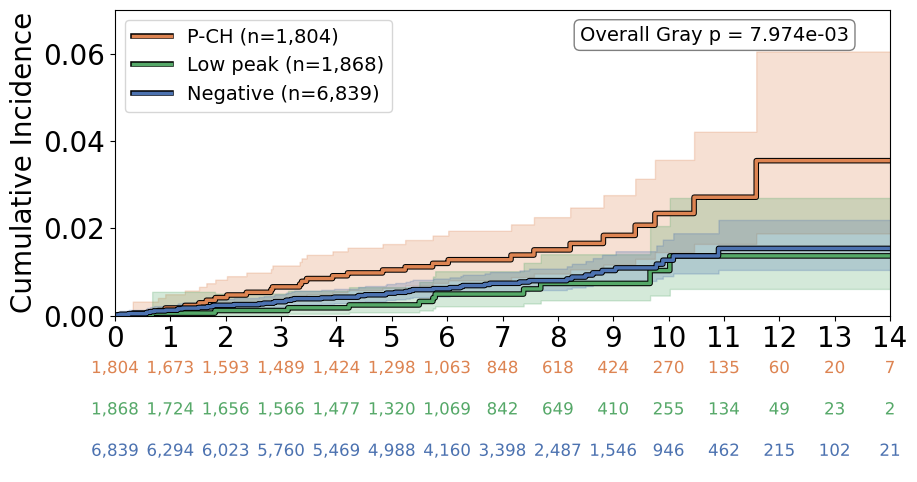

{'P-CH': {np.float64(1.0): 0.0017391842480004938,
  np.float64(5.0): 0.01045623604238755,
  np.float64(10.0): 0.02338935149530272,
  np.float64(12.0): 0.03548832076614069,
  np.float64(14.0): 0.03548832076614069},
 'Low peak': {np.float64(1.0): 0.0005702092025507089,
  np.float64(5.0): 0.0024445652299393042,
  np.float64(10.0): 0.010315359738532329,
  np.float64(12.0): 0.013677684060726898,
  np.float64(14.0): 0.013677684060726898},
 'Negative': {np.float64(1.0): 0.00123377742102307,
  np.float64(5.0): 0.005148319791662718,
  np.float64(10.0): 0.012689323778613856,
  np.float64(12.0): 0.015390707960652415,
  np.float64(14.0): 0.015390707960652415}}

Age>=60
Gray test overall: 0.8362259862487005
Gray test pairwise: {('Low peak', 'Negative'): 0.563320709457341, ('Low peak', 'P-CH'): 0.7975463096731105, ('Negative', 'P-CH'): 0.7626405639252025}


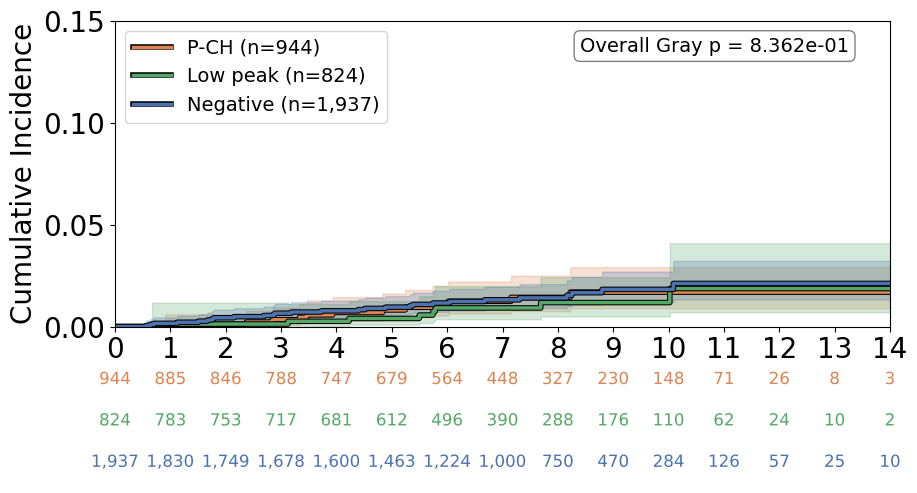

{'P-CH': {np.float64(1.0): 0.0010991517097227804,
  np.float64(5.0): 0.00818353609557515,
  np.float64(10.0): 0.01691752793457474,
  np.float64(12.0): 0.01691752793457474,
  np.float64(14.0): 0.01691752793457474},
 'Low peak': {np.float64(1.0): 0.001256456798923172,
  np.float64(5.0): 0.004001527328941175,
  np.float64(10.0): 0.011794830883479528,
  np.float64(12.0): 0.01869197993088838,
  np.float64(14.0): 0.01869197993088838},
 'Negative': {np.float64(1.0): 0.001601860409856108,
  np.float64(5.0): 0.009559988654172114,
  np.float64(10.0): 0.018280199737190493,
  np.float64(12.0): 0.02119189342005515,
  np.float64(14.0): 0.02119189342005515}}

Age<60
Gray test overall: 3.203162094744805e-05
Gray test pairwise: {('Low peak', 'Negative'): 0.3277715150346979, ('Low peak', 'P-CH'): 0.0010352736713159505, ('Negative', 'P-CH'): 4.5515954125496805e-05}


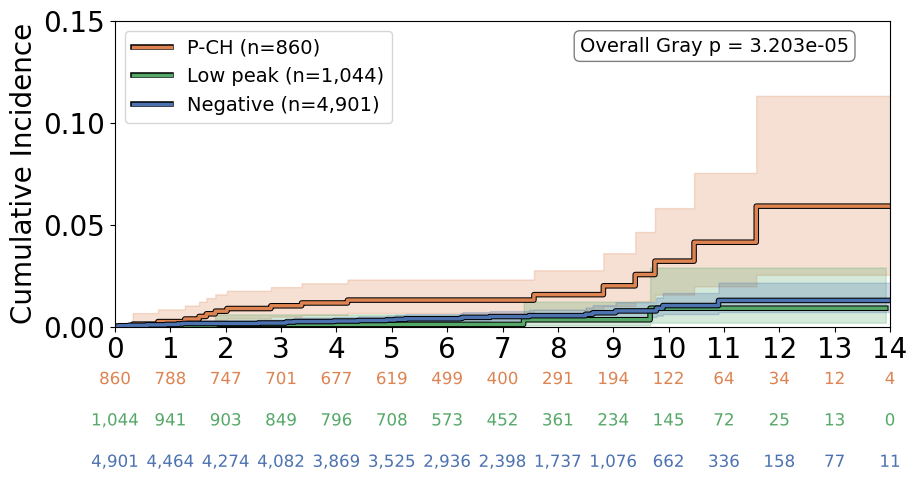

{'P-CH': {np.float64(1.0): 0.00245920095358339,
  np.float64(5.0): 0.013015572960923552,
  np.float64(10.0): 0.03212608349538676,
  np.float64(12.0): 0.059124483857269164,
  np.float64(14.0): 0.059124483857269164},
 'Low peak': {np.float64(1.0): 0.0,
  np.float64(5.0): 0.0010909716041673737,
  np.float64(10.0): 0.009023235410006446,
  np.float64(12.0): 0.009023235410006446,
  np.float64(14.0): 0.009023235410006446},
 'Negative': {np.float64(1.0): 0.0010801395000491825,
  np.float64(5.0): 0.0032805477945888227,
  np.float64(10.0): 0.01033958098201534,
  np.float64(12.0): 0.012854666473588539,
  np.float64(14.0): 0.012854666473588539}}

Data used (N) for outcome analysis = 11,097
--- Overall P-value ---
1.9125614272857366e-42
---------------------------------------
--- Pairwise Log-Rank Test Results ---
                   test_statistic             p    -log2(p)
Low peak MGUS           46.710312  8.229483e-12   36.822335
         Negative       12.651562  3.752519e-04   11.379853
         P-CH           23.883457  1.023475e-06   19.898092
MGUS     Negative      145.615434  1.575483e-33  108.967833
         P-CH            7.165838  7.430496e-03    7.072326
Negative P-CH          113.426618  1.740033e-26   85.571016
---------------------------------------


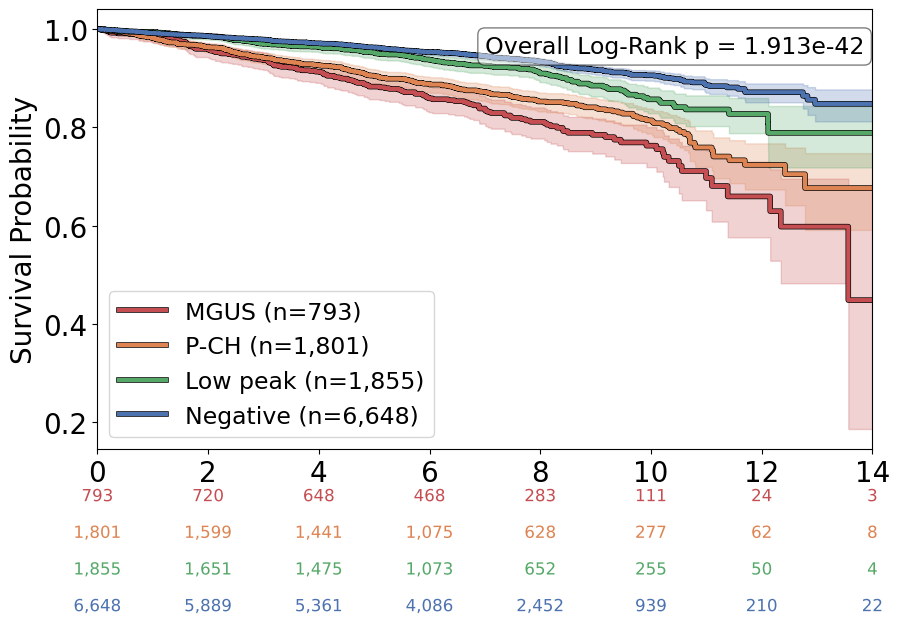

>=60
--- Overall P-value ---
2.235274890671126e-10
---------------------------------------
--- Pairwise Log-Rank Test Results ---
                   test_statistic             p   -log2(p)
Low peak MGUS           17.356833  3.097824e-05  14.978385
         Negative        1.483893  2.231664e-01   2.163808
         P-CH            8.259908  4.053019e-03   7.946787
MGUS     Negative       37.038345  1.158289e-09  29.685358
         P-CH            2.633264  1.046464e-01   3.256406
Negative P-CH           24.010135  9.582991e-07  19.993021
---------------------------------------


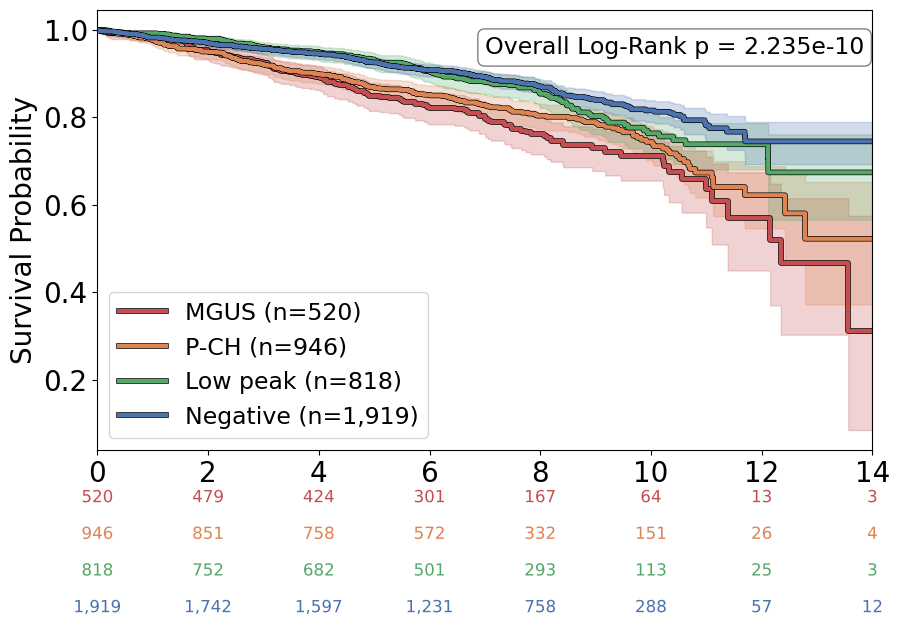

<60
--- Overall P-value ---
9.19356470704864e-10
---------------------------------------
--- Pairwise Log-Rank Test Results ---
                   test_statistic             p   -log2(p)
Low peak MGUS           12.159835  4.882970e-04  10.999954
         Negative        0.388388  5.331479e-01   0.907392
         P-CH           11.196867  8.193554e-04  10.253223
MGUS     Negative       22.521380  2.078177e-06  18.876250
         P-CH            0.679683  4.096959e-01   1.287375
Negative P-CH           29.980482  4.364172e-08  24.449717
---------------------------------------


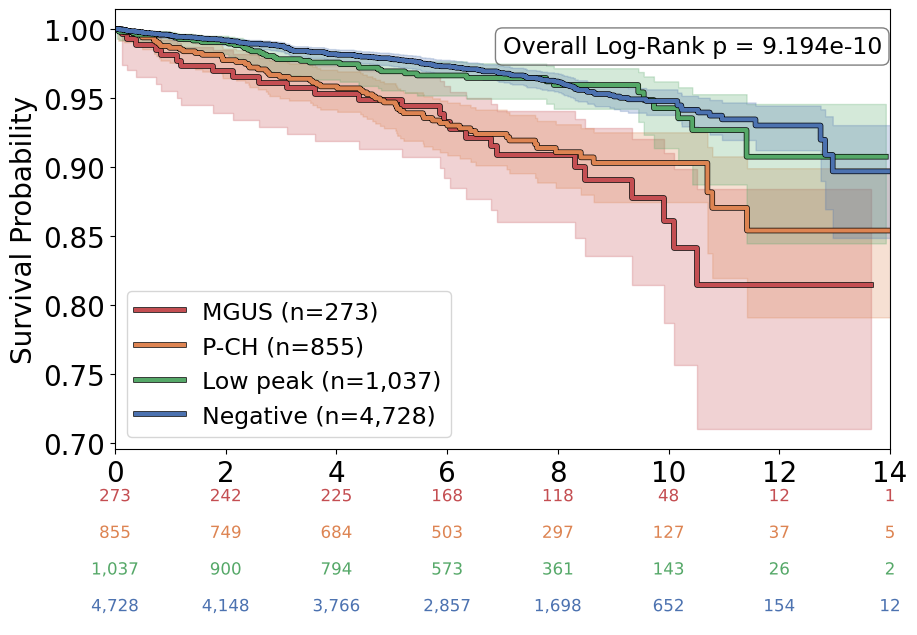

N= 11096 Events= 952 Event rate= 0.08579668348954578
--- CoxPH Model Summary ---
**1. C-statistic (Concordance Index): 0.7307**
--------------------------------------------------
## 2. Proportional Hazards Assumption Test (Schoenfeld Residuals)
Proportional hazard assumption looks okay.
--- P-value Summary of Test Results (Schoenfeld Residuals Test Interpretation) ---


[]

,coef,HR,se(coef),coef lower 95%,coef upper 95%,L_CI,U_CI,cmp to,z,p_value,-log2(p),N_used,N_used_ref
covariate,,,,,,,,,,,,,
Race_binary_Black,-0.000205,0.999795,0.025013,-0.049229,0.048819,0.951963,1.050030,0.0,-0.008202,9.935e-01,0.009472,11096,NaN
Sex_M,0.046501,1.047599,0.018434,0.010372,0.082630,1.010426,1.086140,0.0,2.522633,1.165e-02,6.423776,11096,NaN
Ghobrial_Lab_Diagnosis_v3_simple_Low_peak,-0.000953,0.999048,0.024443,-0.048860,0.046955,0.952314,1.048075,0.0,-0.038979,9.689e-01,0.045570,11096,NaN
Ghobrial_Lab_Diagnosis_v3_simple_MGIP,0.057004,1.058660,0.024666,0.008660,0.105348,1.008697,1.111097,0.0,2.311040,2.083e-02,5.585147,11096,NaN
Ghobrial_Lab_Diagnosis_v3_simple_MGUS,0.093450,1.097955,0.035221,0.024417,0.162482,1.024718,1.176427,0.0,2.653218,7.973e-03,6.970690,11096,NaN
Age,0.003766,1.003773,0.000575,0.002638,0.004894,1.002642,1.004906,0.0,6.545316,5.937e-11,33.971486,11096,NaN


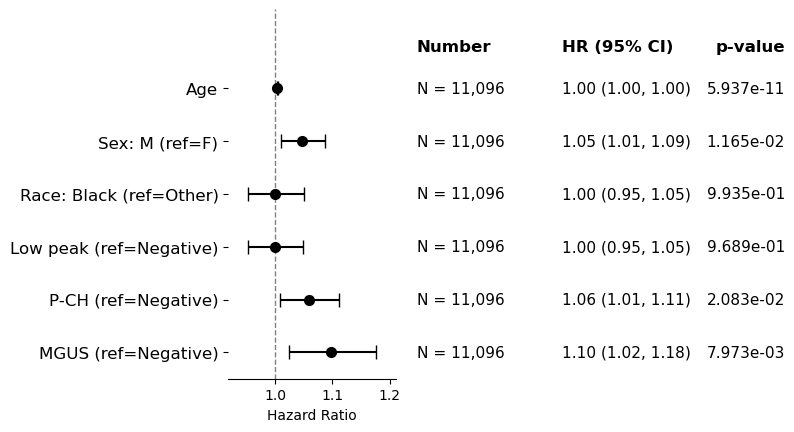

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import numpy as np
import statsmodels.api as sm
from itertools import combinations
from scipy.stats import chi2_contingency, fisher_exact
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from tableone import TableOne
import re
import warnings 
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/MGB_ms.csv', sep=",")

df['Ghobrial_Lab_Diagnosis_v3_simple'] = df['Ghobrial_Lab_Diagnosis_v3_simple'].replace('MGIP', 'P-CH')

colors = sns.color_palette("deep", n_colors=10)
palette = {
    'MGUS' : colors[3],
    'P-CH' : colors[1],       
    'Low peak' : colors[2],
    'Negative' : colors[0],
}

df_prog = df.copy()

analysis_col = [
    ('event_MGUS', 'duration_MGUS_years'),
]

for event_col, duration_col in analysis_col:
    print(event_col)

    df_analysis = df_prog.dropna(subset=[duration_col, event_col]).copy()

    if event_col == 'event_MGUS':
        ########### Remove those negative progression date
        df_analysis = df_analysis[~(df_analysis['Prog_days_MGUS'] < 0)]
  
    ######### status (censored, progression, death)
    conditions = [
        (df_analysis[event_col] == 1),          # progression
        (df_analysis['Mortality'] == 'Yes'),    # death (competing)
        (df_analysis['Mortality'] == 'No')      # alive or no event
    ]
    
    choices = [1, 2, 0]   # 1=progression, 2=death, 0=censored
        
    df_analysis['status'] = np.select(conditions, choices, default=0)
         
    ###### MS diagnosis effect
    sex_to_include = ['F', 'M']
    race_to_include = ['White', 'Black', 'Asian', 'Hispanic', 'Other']
    fh_to_include = ['Yes', 'No']
    diag_to_include = ['Negative', 'Low peak', 'P-CH'] 

    group_col = 'Ghobrial_Lab_Diagnosis_v3_simple'
    
    cox_df_v2 = df_analysis[
        (df_analysis[group_col].isin(diag_to_include))
    ]

    ## Race
    cox_df_v2['Race_binary'] = np.where(cox_df_v2['Race_v2'] != 'Black', 'non-Black', 'Black')
        
    cox_df_v2 = cox_df_v2.dropna(subset=[event_col, duration_col, "status"])
    cox_df_v2 = cox_df_v2[cox_df_v2[duration_col] >=0]
    
    print(f'Data used (N) for MGUS progression (Low peak, P-CH and Negative) = {len(cox_df_v2):,}')   

    ######### Numbers ###########
    diag_col = 'Ghobrial_Lab_Diagnosis_v3_simple' 

    print(cox_df_v2[diag_col].value_counts())
    
    summary = cox_df_v2.groupby([diag_col, 'major_type']).agg({
        'Conc_1': ['min', 'max', 'count'], 
        event_col: ['sum']                 
    })
    
    summary.columns = ['Conc_Min', 'Conc_Max', 'Total_N', 'Event_Count']
    summary['Event_Rate(%)'] = (summary['Event_Count'] / summary['Total_N'] * 100).round(1)
    
    display(summary)

    ### how many <0.2g/L
    for ig_type in ['IgG', 'IgA', 'IgM']:
        igg_high = cox_df_v2[
            (cox_df_v2[diag_col] == 'P-CH') & 
            (cox_df_v2['major_type'] == ig_type)
        ].copy()
        
        igg_high['Conc_Group'] = igg_high['Conc_1'].apply(
            lambda x: f'{ig_type} P-CH-High (< 0.2)' if x < 0.2 else f'{ig_type} P-CH-High (>= 0.2)'
        )
        
        igg_summary = igg_high.groupby('Conc_Group').agg({
            'Conc_1': ['min', 'max', 'count'],
            event_col: ['sum']
        })
        
        igg_summary.columns = ['Conc_Min', 'Conc_Max', 'Total_N', 'Event_Count']
        igg_summary['Event_Rate(%)'] = (igg_summary['Event_Count'] / igg_summary['Total_N'] * 100).round(1)
        
        display(igg_summary)


    ######### CUMULATIVE INCIDENCE FUNCTION
    res = plot_cif_aj_with_graytest(
        cox_df_v2, duration_col, "status", group_col,
        event_of_interest=1,
        group_order=diag_to_include[::-1],
        palette=palette,
        ylim=(0, 0.07),
        figsize=(10,6),
        do_gray_test=True,
        time_points=np.arange(0, 15, 1),
        overall_pval=True,
        return_cif_at=[1, 5, 10, 12, 14],
        save='../00.Figures/MGB_total_cumulative_MGUS_progression.pdf',
    )

    display(res['cif_at_times'])
    
    for age in [60]:
        for mode in ['>=', '<']:
            if mode == "<":
                cut_cox_df_v2 = cox_df_v2[cox_df_v2['Age'] < age]
            else:
                cut_cox_df_v2 = cox_df_v2[cox_df_v2['Age'] >= age]
            mode_age = mode+str(age)
            print(f'Age{mode_age}')
            res2 = plot_cif_aj_with_graytest(
                cut_cox_df_v2, duration_col, "status", group_col,
                event_of_interest=1,
                group_order=diag_to_include[::-1],
                palette=palette,
                ylim=(0, 0.15),
                figsize=(10,6),
                do_gray_test=True,
                overall_pval=True,
                return_cif_at=[1, 5, 10, 12, 14],
                save=f'../00.Figures/MGB_total_cumulative_MGUS_progression_{mode_age}.pdf'
            )

            display(res2['cif_at_times'])


############################################## Survival
df_analysis_v2 = df_prog.copy()

for anal_type in ['Total']:
    ###### MS diagnosis effect
    sex_to_include = ['F', 'M']
    race_to_include = ['White', 'Black', 'Asian', 'Hispanic', 'Other']
    fh_to_include = ['Yes', 'No']
    if anal_type == 'Total':
        diag_to_include = ['Negative', 'Low peak', 'P-CH', 'MGUS'] 
    elif anal_type == 'NoMGUS':
        diag_to_include = ['Negative', 'Low peak', 'P-CH'] 
    
    group_col = 'Ghobrial_Lab_Diagnosis_v3_simple'
    
    cox_df_v2 = df_analysis_v2[
        (df_analysis_v2['Race_v2'].isin(race_to_include)) &
        (df_analysis_v2['Sex'].isin(sex_to_include)) &
        (df_analysis_v2[group_col].isin(diag_to_include))
    ]

    ## Race
    cox_df_v2['Race_binary'] = np.where(cox_df_v2['Race_v2'] != 'Black', 'non-Black', 'Black')
    
    conditions_mortality = [
        (cox_df_v2['Mortality'] == 'Yes'), 
        (cox_df_v2['Mortality'] == 'No')
    ]
    
    status_mortality = [1, 0]   
            
    cox_df_v2['status_mortality'] = np.select(conditions_mortality, status_mortality, default=0)
             
    choices_mortality = [
        cox_df_v2['Mort_Days'],      
        cox_df_v2['Last_FU_Days']    
    ]
    
    cox_df_v2['duration_mortality'] = np.select(conditions_mortality, choices_mortality, default=np.nan)
    cox_df_v2['duration_mortality_years'] = cox_df_v2['duration_mortality'] / 365
    
    event_col = 'status_mortality'
    duration_col = 'duration_mortality_years'
    
    cox_df_v2 = cox_df_v2.dropna(subset=[event_col, duration_col])
    cox_df_v2 = cox_df_v2[cox_df_v2[duration_col] >=0]

    print(f'Data used (N) for outcome analysis = {len(cox_df_v2):,}')  
    
    plot_kaplan_meier(
        cox_df_v2, 
        duration_col=duration_col, 
        event_col=event_col, 
        y_label='Survival Probability',
        group_col=group_col,
        group_order=diag_to_include[::-1],
        palette = palette, 
        overall_pval=True,
        time_points=[0, 2, 4, 6, 8, 10, 12, 14],
        save=f'../00.Figures/OS_KM_plot_{anal_type}.pdf',
    )
    
    for age in [60]:
        for mode in ['>=', '<']:
            if mode == "<":
                cut_cox_df_v2 = cox_df_v2[cox_df_v2['Age'] < age]
            else:
                cut_cox_df_v2 = cox_df_v2[cox_df_v2['Age'] >= age]
    
            mode_age = mode+str(age)
            print(mode_age)
            plot_kaplan_meier(
                cut_cox_df_v2, 
                duration_col=duration_col, 
                event_col=event_col, 
                y_label='Survival Probability',
                group_col=group_col,
                group_order=diag_to_include[::-1],
                palette = palette, 
                overall_pval=True,
                time_points=[0, 2, 4, 6, 8, 10, 12, 14],
                save=f'../00.Figures/OS_KM_plot_{mode_age}_{anal_type}.pdf',
            )
    
    ################ Cox
    cox_df_v2['Ghobrial_Lab_Diagnosis_v3_simple'] = cox_df_v2['Ghobrial_Lab_Diagnosis_v3_simple'].replace(
        'P-CH', 'MGIP')

    
    cox_results_df_v2 = run_cox_analysis_and_format(
        cox_df_v2,
        duration_col=duration_col,
        event_col=event_col,
        covariates=['Age', 'Sex', 'Race_binary', group_col],
        reference_group_dict={
            'Race_binary' : 'non-Black', 
            'Sex': 'F',
            group_col : 'Negative',
        },
        penalizer = 0.05,
        model_QC = None,
    )
    display(cox_results_df_v2)
    
    rename_dict = {
        'Sex_M' : 'Sex: M (ref=F)',
        'Sex_F' : 'Sex: F (ref=M)',
        'Race_v2_Black' : 'Race: Black (ref=White)', 
        'Race_v2_Asian' : 'Race: Asian (ref=White)',
        'Race_v2_Hispanic' : 'Race: Hispanic (ref=White)',
        'Race_v2_Other' : 'Race: Other (ref=White)',
        'Race_binary_Black' : 'Race: Black (ref=Other)',
        'clonality' : 'Number of clone',
        'major_conc' : 'Major M-protein concentration (g/L)',
        'FLCRatio' : 'FLC Ratio',
        'hema_fh_Yes' : 'Family Hx of Blood Cancer: Yes (ref=No)',
        'hema_fh_mm_Yes' : 'Family Hx of Multiple Myeloma: Yes (ref=No)',
        'major_type_IgG' : 'Major M-protein Isotype: IgG (ref=IgM)',
        'major_type_IgA' : 'Major M-protein Isotype: IgA (ref=IgM)',
        'fh_degree_new: First (ref=Others)' : 'Degree of Family Hx of Blood Cancer: First (ref=Others/None)',
        'Ghobrial_Lab_Diagnosis_v3_simple_MGIP' : 'P-CH (ref=Negative)',              
        'Ghobrial_Lab_Diagnosis_v3_simple_MGUS' : 'MGUS (ref=Negative)',
        'Ghobrial_Lab_Diagnosis_v3_simple_Low_peak' : 'Low peak (ref=Negative)',
        'isotype_v2_IgG' : 'IgG (ref=Negative)',
        'isotype_v2_IgA' : 'IgA (ref=Negative)',
        'isotype_v2_IgM' : 'IgM (ref=Negative)',
    }
    
    order = [
        'Age', 
        'Sex: M (ref=F)', 
        'Sex: F (ref=M)',
        'BMI', 
        'Race: Black (ref=Other)',
        'Race: Black (ref=White)', 
        'Race: Asian (ref=White)',
        'Race: Hispanic (ref=White)',
        'Race: Other (ref=White)',
        'Family Hx of Blood Cancer: Yes (ref=No)',
        'Family Hx of Multiple Myeloma: Yes (ref=No)',
        'Degree of Family Hx of Blood Cancer: First (ref=Others/None)',
        'Number of clone',
        'Major M-protein concentration (g/L)',
        'FLC Ratio',
        'Major M-protein Isotype: IgG (ref=IgM)',
        'Major M-protein Isotype: IgA (ref=IgM)',
        'Low peak (ref=Negative)',
        'P-CH (ref=Negative)',         
        'MGUS (ref=Negative)',
        'IgG (ref=Negative)', 'IgA (ref=Negative)', 'IgM (ref=Negative)',
    ]
    
    include_cont = ['Age', 'BMI',]
    include_cat  = {
        'Sex': ['M'], 
        group_col : ['Low peak', 'P-CH', 'MGUS'], 
    }  
    
    plot_forest_from_res_filtered(
        cox_results_df_v2,
        include_cont=include_cont,  
        include_cat=include_cat,    
        xlog=False,
        rename_dict=rename_dict,
        save=f'../00.Figures/Cox_P-CH_OS_{anal_type}.pdf', 
        order=order[::-1],
        risk='HR',
    )


## Autoimmune association (logistic)

,Case,Total,%
Rheumatoid Arthritis,798,10926,7.3
Psoriasis,414,10926,3.8
Hashimoto thyroiditis,408,10926,3.7
Diabetes mellitus type 1,403,10926,3.7
Multiple Sclerosis,233,10926,2.1
Crohn Disease,213,10926,1.9
Systemic Lupus Erythematosus,212,10926,1.9
Ulcerative Colitis,207,10926,1.9
Sjogren Disease,198,10926,1.8
Celiac Disease,173,10926,1.6


***************************** Rheumatoid Arthritis *****************************
*************** Time difference between MS and disease diagnosis (Case only) ***************
- AD After MS: n=190 (23.8%)
- AD Before MS or at the time of MS: n=608 (76.2%)
- Within 1 Year (Abs): n=160 (20.1%)
- Within 2 Years (Abs): n=242 (30.3%)
- Within 3 Years (Abs): n=310 (38.8%)
- Over 3 Years (Abs): n=488 (61.2%)
*************** Had AD before MS ***************
Total N used: 10736
Total events: 608
Total non-events: 10128
Event rate: 0.0566

Event counts by group:


,group,N,Events,Non_events,Event_rate
0,Negative,6488,322,6166,0.049630
1,Low peak,1811,101,1710,0.055770
2,MGIP,1742,136,1606,0.078071
3,MGUS,695,49,646,0.070504


AUC: 0.6689


,N_used_ref,N_used,OR,L_CI,U_CI,p_value,OR (95% CI)
Intercept,NaN,10736,0.008074,0.005562,0.011720,9.48e-142,"0.01 (0.01, 0.01)"
Sex: F (ref=M),4577.0,6159,3.114132,2.552569,3.799239,4.24e-29,"3.11 (2.55, 3.80)"
group: Low peak (ref=Negative),6488.0,1811,1.067157,0.844492,1.348532,5.86e-01,"1.07 (0.84, 1.35)"
group: MGIP (ref=Negative),6488.0,1742,1.428750,1.151400,1.772907,1.19e-03,"1.43 (1.15, 1.77)"
group: MGUS (ref=Negative),6488.0,695,1.255712,0.909868,1.733014,1.66e-01,"1.26 (0.91, 1.73)"
Race_binary: Black (ref=non-Black),9060.0,1676,1.385397,1.120779,1.712490,2.58e-03,"1.39 (1.12, 1.71)"
Age (per 10),NaN,10736,1.220997,1.153735,1.292180,4.97e-12,"1.22 (1.15, 1.29)"


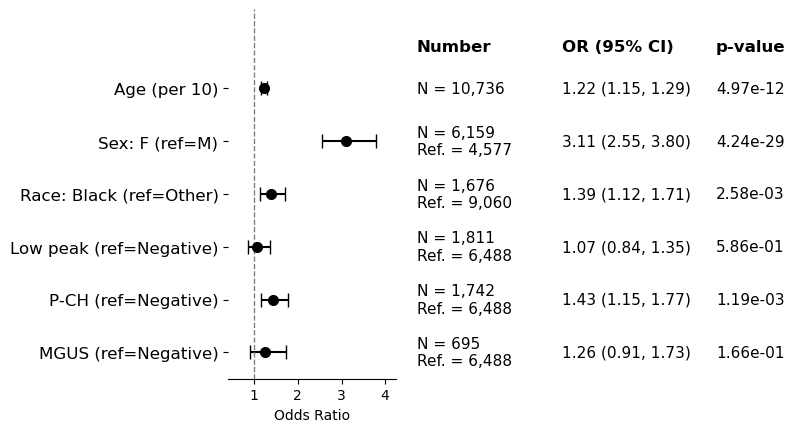

***************************** Psoriasis *****************************
*************** Time difference between MS and disease diagnosis (Case only) ***************
- AD After MS: n=21 (5.1%)
- AD Before MS or at the time of MS: n=393 (94.9%)
- Within 1 Year (Abs): n=43 (10.4%)
- Within 2 Years (Abs): n=65 (15.7%)
- Within 3 Years (Abs): n=87 (21.0%)
- Over 3 Years (Abs): n=327 (79.0%)
*************** Had AD before MS ***************
Total N used: 10905
Total events: 393
Total non-events: 10512
Event rate: 0.0360

Event counts by group:


,group,N,Events,Non_events,Event_rate
0,Negative,6594,206,6388,0.031241
1,Low peak,1837,69,1768,0.037561
2,MGIP,1767,94,1673,0.053198
3,MGUS,707,24,683,0.033946


AUC: 0.6296


,N_used_ref,N_used,OR,L_CI,U_CI,p_value,OR (95% CI)
Intercept,NaN,10905,0.010157,0.006486,0.015905,1.80e-89,"0.01 (0.01, 0.02)"
Sex: F (ref=M),4623.0,6282,0.943580,0.768851,1.158018,5.78e-01,"0.94 (0.77, 1.16)"
group: Low peak (ref=Negative),6594.0,1837,1.058621,0.799363,1.401964,6.91e-01,"1.06 (0.80, 1.40)"
group: MGIP (ref=Negative),6594.0,1767,1.391765,1.076392,1.799539,1.17e-02,"1.39 (1.08, 1.80)"
group: MGUS (ref=Negative),6594.0,707,0.803559,0.517756,1.247124,3.29e-01,"0.80 (0.52, 1.25)"
Race_binary: Black (ref=non-Black),9206.0,1699,0.530838,0.369762,0.762081,5.98e-04,"0.53 (0.37, 0.76)"
Age (per 10),NaN,10905,1.275383,1.186880,1.370485,3.38e-11,"1.28 (1.19, 1.37)"


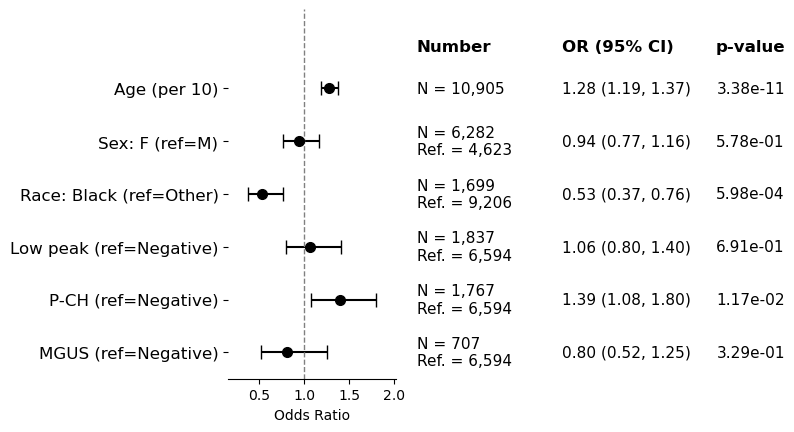

***************************** Hashimoto thyroiditis *****************************
*************** Time difference between MS and disease diagnosis (Case only) ***************
- AD After MS: n=159 (39.0%)
- AD Before MS or at the time of MS: n=249 (61.0%)
- Within 1 Year (Abs): n=108 (26.5%)
- Within 2 Years (Abs): n=151 (37.0%)
- Within 3 Years (Abs): n=192 (47.1%)
- Over 3 Years (Abs): n=216 (52.9%)
*************** Had AD before MS ***************
Total N used: 10767
Total events: 249
Total non-events: 10518
Event rate: 0.0231

Event counts by group:


,group,N,Events,Non_events,Event_rate
0,Negative,6502,160,6342,0.024608
1,Low peak,1815,41,1774,0.022590
2,MGIP,1752,40,1712,0.022831
3,MGUS,698,8,690,0.011461


AUC: 0.6991


,N_used_ref,N_used,OR,L_CI,U_CI,p_value,OR (95% CI)
Intercept,NaN,10767,0.006178,0.003486,0.010950,5.57e-68,"0.01 (0.00, 0.01)"
Sex: F (ref=M),4609.0,6158,5.140381,3.548144,7.447137,4.90e-18,"5.14 (3.55, 7.45)"
group: Low peak (ref=Negative),6502.0,1815,0.949600,0.667456,1.351011,7.74e-01,"0.95 (0.67, 1.35)"
group: MGIP (ref=Negative),6502.0,1752,0.884983,0.617198,1.268951,5.06e-01,"0.88 (0.62, 1.27)"
group: MGUS (ref=Negative),6502.0,698,0.504548,0.244223,1.042361,6.46e-02,"0.50 (0.24, 1.04)"
Race_binary: Black (ref=non-Black),9085.0,1682,0.268679,0.149898,0.481585,1.01e-05,"0.27 (0.15, 0.48)"
Age (per 10),NaN,10767,1.063765,0.978820,1.156082,1.45e-01,"1.06 (0.98, 1.16)"


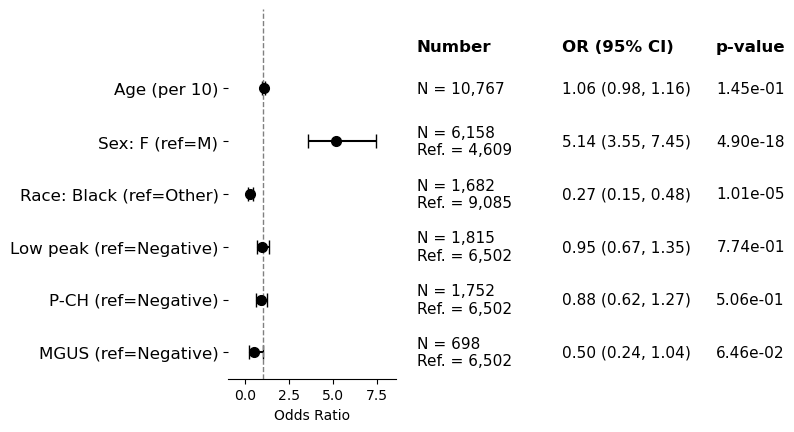

***************************** Diabetes mellitus type 1 *****************************
*************** Time difference between MS and disease diagnosis (Case only) ***************
- AD After MS: n=15 (3.7%)
- AD Before MS or at the time of MS: n=388 (96.3%)
- Within 1 Year (Abs): n=23 (5.7%)
- Within 2 Years (Abs): n=46 (11.4%)
- Within 3 Years (Abs): n=65 (16.1%)
- Over 3 Years (Abs): n=338 (83.9%)
*************** Had AD before MS ***************
Total N used: 10911
Total events: 388
Total non-events: 10523
Event rate: 0.0356

Event counts by group:


,group,N,Events,Non_events,Event_rate
0,Negative,6596,228,6368,0.034566
1,Low peak,1841,57,1784,0.030961
2,MGIP,1766,66,1700,0.037373
3,MGUS,708,37,671,0.052260


AUC: 0.6922


,N_used_ref,N_used,OR,L_CI,U_CI,p_value,OR (95% CI)
Intercept,NaN,10911,0.004397,0.002709,0.007137,7.01e-107,"0.00 (0.00, 0.01)"
Sex: F (ref=M),4622.0,6289,0.722424,0.587772,0.887924,2.01e-03,"0.72 (0.59, 0.89)"
group: Low peak (ref=Negative),6596.0,1841,0.713274,0.528447,0.962744,2.72e-02,"0.71 (0.53, 0.96)"
group: MGIP (ref=Negative),6596.0,1766,0.816442,0.612767,1.087815,1.66e-01,"0.82 (0.61, 1.09)"
group: MGUS (ref=Negative),6596.0,708,0.940439,0.651264,1.358014,7.43e-01,"0.94 (0.65, 1.36)"
Race_binary: Black (ref=non-Black),9216.0,1695,2.550656,2.024097,3.214198,2.07e-15,"2.55 (2.02, 3.21)"
Age (per 10),NaN,10911,1.473322,1.365700,1.589425,1.33e-23,"1.47 (1.37, 1.59)"


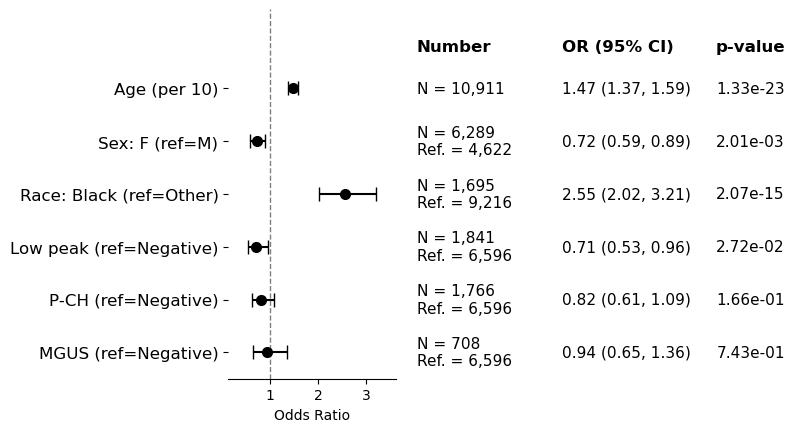

***************************** Multiple Sclerosis *****************************
*************** Time difference between MS and disease diagnosis (Case only) ***************
- AD After MS: n=40 (17.2%)
- AD Before MS or at the time of MS: n=193 (82.8%)
- Within 1 Year (Abs): n=45 (19.3%)
- Within 2 Years (Abs): n=66 (28.3%)
- Within 3 Years (Abs): n=84 (36.1%)
- Over 3 Years (Abs): n=149 (63.9%)
*************** Had AD before MS ***************
Total N used: 10886
Total events: 193
Total non-events: 10693
Event rate: 0.0177

Event counts by group:


,group,N,Events,Non_events,Event_rate
0,Negative,6573,115,6458,0.017496
1,Low peak,1837,24,1813,0.013065
2,MGIP,1768,43,1725,0.024321
3,MGUS,708,11,697,0.015537


AUC: 0.6235


,N_used_ref,N_used,OR,L_CI,U_CI,p_value,OR (95% CI)
Intercept,NaN,10886,0.014113,0.007979,0.024963,1.50e-48,"0.01 (0.01, 0.02)"
Sex: F (ref=M),4626.0,6260,2.267692,1.623973,3.166572,1.54e-06,"2.27 (1.62, 3.17)"
group: Low peak (ref=Negative),6573.0,1837,0.801647,0.512881,1.252997,3.32e-01,"0.80 (0.51, 1.25)"
group: MGIP (ref=Negative),6573.0,1768,1.503925,1.043726,2.167034,2.86e-02,"1.50 (1.04, 2.17)"
group: MGUS (ref=Negative),6573.0,708,1.054624,0.557714,1.994272,8.70e-01,"1.05 (0.56, 1.99)"
Race_binary: Black (ref=non-Black),9194.0,1692,0.729313,0.469682,1.132461,1.60e-01,"0.73 (0.47, 1.13)"
Age (per 10),NaN,10886,0.942247,0.858491,1.034175,2.10e-01,"0.94 (0.86, 1.03)"


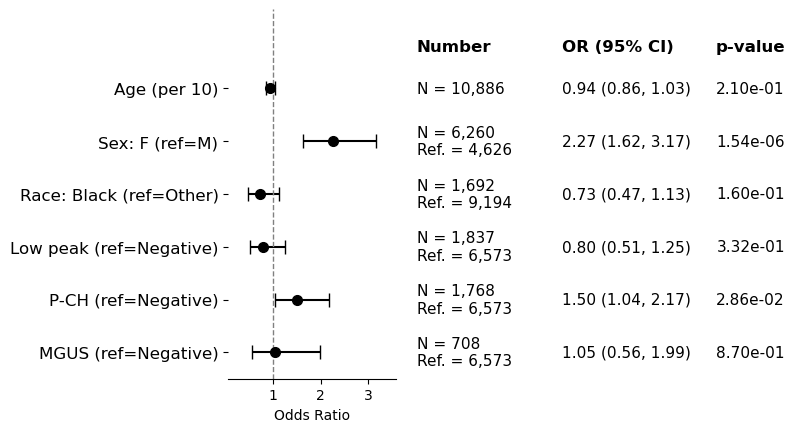

***************************** Crohn Disease *****************************
*************** Time difference between MS and disease diagnosis (Case only) ***************
- AD After MS: n=9 (4.2%)
- AD Before MS or at the time of MS: n=204 (95.8%)
- Within 1 Year (Abs): n=26 (12.2%)
- Within 2 Years (Abs): n=41 (19.2%)
- Within 3 Years (Abs): n=56 (26.3%)
- Over 3 Years (Abs): n=157 (73.7%)
*************** Had AD before MS ***************
Total N used: 10917
Total events: 204
Total non-events: 10713
Event rate: 0.0187

Event counts by group:


,group,N,Events,Non_events,Event_rate
0,Negative,6600,103,6497,0.015606
1,Low peak,1839,36,1803,0.019576
2,MGIP,1770,41,1729,0.023164
3,MGUS,708,24,684,0.033898


AUC: 0.6095


,N_used_ref,N_used,OR,L_CI,U_CI,p_value,OR (95% CI)
Intercept,NaN,10917,0.043138,0.025980,0.071630,5.80e-34,"0.04 (0.03, 0.07)"
Sex: F (ref=M),4630.0,6287,0.926606,0.697583,1.230821,5.99e-01,"0.93 (0.70, 1.23)"
group: Low peak (ref=Negative),6600.0,1839,1.391673,0.945347,2.048724,9.39e-02,"1.39 (0.95, 2.05)"
group: MGIP (ref=Negative),6600.0,1770,1.748249,1.200936,2.544994,3.55e-03,"1.75 (1.20, 2.54)"
group: MGUS (ref=Negative),6600.0,708,2.881464,1.800229,4.612099,1.04e-05,"2.88 (1.80, 4.61)"
Race_binary: Black (ref=non-Black),9217.0,1700,0.615258,0.393379,0.962283,3.33e-02,"0.62 (0.39, 0.96)"
Age (per 10),NaN,10917,0.827883,0.756371,0.906157,4.17e-05,"0.83 (0.76, 0.91)"


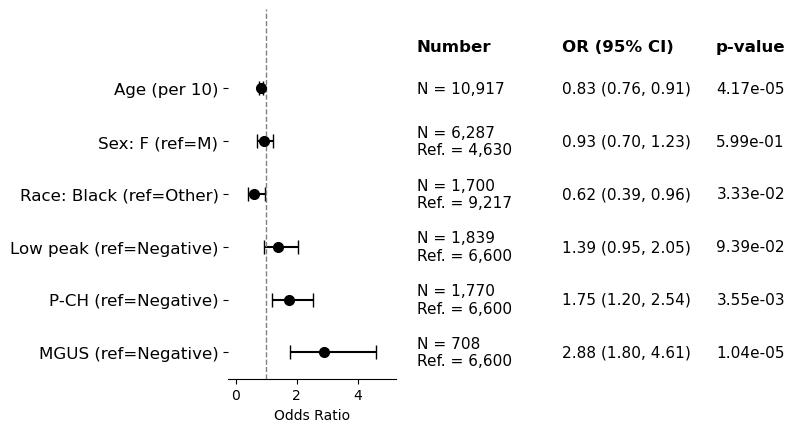

***************************** Ulcerative Colitis *****************************
*************** Time difference between MS and disease diagnosis (Case only) ***************
- AD After MS: n=9 (4.3%)
- AD Before MS or at the time of MS: n=198 (95.7%)
- Within 1 Year (Abs): n=26 (12.6%)
- Within 2 Years (Abs): n=44 (21.3%)
- Within 3 Years (Abs): n=55 (26.6%)
- Over 3 Years (Abs): n=152 (73.4%)
*************** Had AD before MS ***************
Total N used: 10917
Total events: 198
Total non-events: 10719
Event rate: 0.0181

Event counts by group:


,group,N,Events,Non_events,Event_rate
0,Negative,6598,113,6485,0.017126
1,Low peak,1841,24,1817,0.013036
2,MGIP,1769,41,1728,0.023177
3,MGUS,709,20,689,0.028209


AUC: 0.5987


,N_used_ref,N_used,OR,L_CI,U_CI,p_value,OR (95% CI)
Intercept,NaN,10917,0.035254,0.020836,0.059648,1.12e-35,"0.04 (0.02, 0.06)"
Sex: F (ref=M),4630.0,6287,0.670795,0.504334,0.892199,6.07e-03,"0.67 (0.50, 0.89)"
group: Low peak (ref=Negative),6598.0,1841,0.776248,0.496578,1.213428,2.66e-01,"0.78 (0.50, 1.21)"
group: MGIP (ref=Negative),6598.0,1769,1.434670,0.989958,2.079156,5.66e-02,"1.43 (0.99, 2.08)"
group: MGUS (ref=Negative),6598.0,709,1.806338,1.096259,2.976356,2.03e-02,"1.81 (1.10, 2.98)"
Race_binary: Black (ref=non-Black),9216.0,1701,0.659995,0.421682,1.032991,6.91e-02,"0.66 (0.42, 1.03)"
Age (per 10),NaN,10917,0.915953,0.834803,1.004992,6.36e-02,"0.92 (0.83, 1.00)"


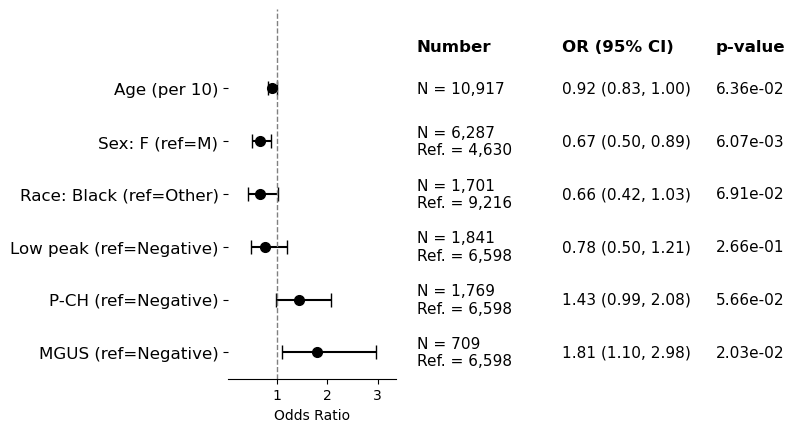

***************************** Sjogren Disease *****************************
*************** Time difference between MS and disease diagnosis (Case only) ***************
- AD After MS: n=80 (40.4%)
- AD Before MS or at the time of MS: n=118 (59.6%)
- Within 1 Year (Abs): n=56 (28.3%)
- Within 2 Years (Abs): n=75 (37.9%)
- Within 3 Years (Abs): n=93 (47.0%)
- Over 3 Years (Abs): n=105 (53.0%)
*************** Had AD before MS ***************
Total N used: 10846
Total events: 118
Total non-events: 10728
Event rate: 0.0109

Event counts by group:


,group,N,Events,Non_events,Event_rate
0,Negative,6561,67,6494,0.010212
1,Low peak,1822,21,1801,0.011526
2,MGIP,1760,21,1739,0.011932
3,MGUS,703,9,694,0.012802


AUC: 0.6998


,N_used_ref,N_used,OR,L_CI,U_CI,p_value,OR (95% CI)
Intercept,NaN,10846,0.001164,0.000488,0.002775,1.84e-52,"0.00 (0.00, 0.00)"
Sex: F (ref=M),4629.0,6217,5.276354,3.101726,8.975620,8.47e-10,"5.28 (3.10, 8.98)"
group: Low peak (ref=Negative),6561.0,1822,1.093226,0.663539,1.801163,7.26e-01,"1.09 (0.66, 1.80)"
group: MGIP (ref=Negative),6561.0,1760,1.021920,0.615924,1.695533,9.33e-01,"1.02 (0.62, 1.70)"
group: MGUS (ref=Negative),6561.0,703,1.157349,0.563532,2.376894,6.91e-01,"1.16 (0.56, 2.38)"
Race_binary: Black (ref=non-Black),9158.0,1688,0.809626,0.468825,1.398164,4.49e-01,"0.81 (0.47, 1.40)"
Age (per 10),NaN,10846,1.208439,1.067685,1.367749,2.73e-03,"1.21 (1.07, 1.37)"


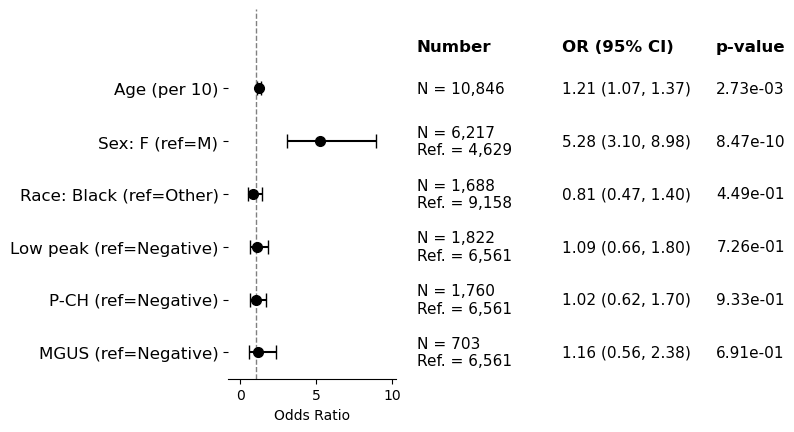

***************************** Systemic Lupus Erythematosus *****************************
*************** Time difference between MS and disease diagnosis (Case only) ***************
- AD After MS: n=118 (55.7%)
- AD Before MS or at the time of MS: n=94 (44.3%)
- Within 1 Year (Abs): n=86 (40.6%)
- Within 2 Years (Abs): n=132 (62.3%)
- Within 3 Years (Abs): n=157 (74.1%)
- Over 3 Years (Abs): n=55 (25.9%)
*************** Had AD before MS ***************
Total N used: 10808
Total events: 94
Total non-events: 10714
Event rate: 0.0087

Event counts by group:


,group,N,Events,Non_events,Event_rate
0,Negative,6533,56,6477,0.008572
1,Low peak,1828,16,1812,0.008753
2,MGIP,1748,16,1732,0.009153
3,MGUS,699,6,693,0.008584


AUC: 0.7746


,N_used_ref,N_used,OR,L_CI,U_CI,p_value,OR (95% CI)
Intercept,NaN,10808,0.008172,0.003099,0.021550,2.58e-22,"0.01 (0.00, 0.02)"
Sex: F (ref=M),4616.0,6192,8.166747,3.768314,17.699100,1.03e-07,"8.17 (3.77, 17.70)"
group: Low peak (ref=Negative),6533.0,1828,1.377148,0.782401,2.423997,2.67e-01,"1.38 (0.78, 2.42)"
group: MGIP (ref=Negative),6533.0,1748,1.647258,0.927403,2.925868,8.86e-02,"1.65 (0.93, 2.93)"
group: MGUS (ref=Negative),6533.0,699,1.932412,0.810138,4.609358,1.37e-01,"1.93 (0.81, 4.61)"
Race_binary: Black (ref=non-Black),9139.0,1669,1.475013,0.901210,2.414156,1.22e-01,"1.48 (0.90, 2.41)"
Age (per 10),NaN,10808,0.679326,0.592770,0.778521,2.69e-08,"0.68 (0.59, 0.78)"


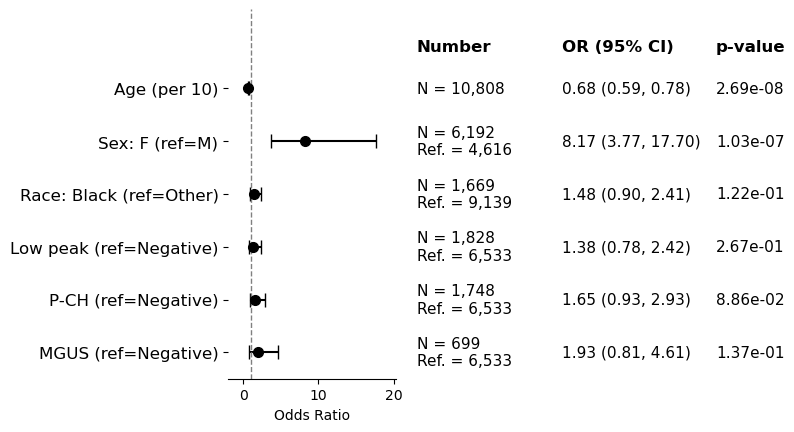

***************************** Celiac Disease *****************************
*************** Time difference between MS and disease diagnosis (Case only) ***************
- AD After MS: n=71 (41.0%)
- AD Before MS or at the time of MS: n=102 (59.0%)
- Within 1 Year (Abs): n=38 (22.0%)
- Within 2 Years (Abs): n=67 (38.7%)
- Within 3 Years (Abs): n=79 (45.7%)
- Over 3 Years (Abs): n=94 (54.3%)
*************** Had AD before MS ***************
Total N used: 10855
Total events: 102
Total non-events: 10753
Event rate: 0.0094

Event counts by group:


,group,N,Events,Non_events,Event_rate
0,Negative,6560,69,6491,0.010518
1,Low peak,1833,8,1825,0.004364
2,MGIP,1758,17,1741,0.009670
3,MGUS,704,8,696,0.011364


AUC: 0.6609


,N_used_ref,N_used,OR,L_CI,U_CI,p_value,OR (95% CI)
Intercept,NaN,10855,0.010841,0.005030,0.023365,7.56e-31,"0.01 (0.01, 0.02)"
Sex: F (ref=M),4614.0,6241,2.187593,1.384111,3.457499,8.03e-04,"2.19 (1.38, 3.46)"
group: Low peak (ref=Negative),6560.0,1833,0.452026,0.216124,0.945419,3.49e-02,"0.45 (0.22, 0.95)"
group: MGIP (ref=Negative),6560.0,1758,0.998517,0.578207,1.724359,9.96e-01,"1.00 (0.58, 1.72)"
group: MGUS (ref=Negative),6560.0,704,1.368765,0.640943,2.923066,4.17e-01,"1.37 (0.64, 2.92)"
Race_binary: Black (ref=non-Black),9159.0,1696,0.324255,0.141706,0.741968,7.66e-03,"0.32 (0.14, 0.74)"
Age (per 10),NaN,10855,0.911953,0.802947,1.035758,1.56e-01,"0.91 (0.80, 1.04)"


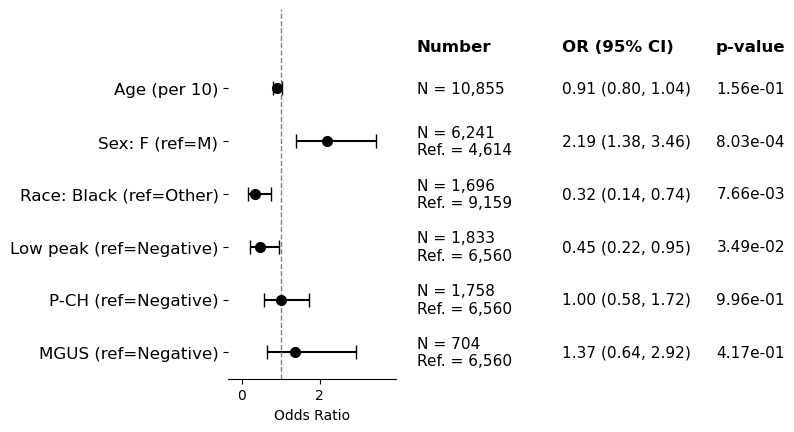

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import numpy as np
import statsmodels.api as sm
from itertools import combinations
from scipy.stats import chi2_contingency, fisher_exact
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from tableone import TableOne
import re
import warnings 
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/MGB_ms.csv', sep=",")

df['Ghobrial_Lab_Diagnosis_v3_simple_isotype'] = np.where(
    df['Ghobrial_Lab_Diagnosis_v3_simple'].isin(['MGIP', 'MGUS']),
    df['major_type'].astype(str) + '_' + df['Ghobrial_Lab_Diagnosis_v3_simple'].astype(str),
    df['Ghobrial_Lab_Diagnosis_v3_simple']
)


df_analysis_v3 = df.copy()

diag_to_include = ['Negative', 'Low peak', 'MGIP', 'MGUS']
race_to_include = ['White', 'Black', 'Asian', 'Hispanic', 'Other']

input_logit_df = df_analysis_v3[
    (df_analysis_v3['Ghobrial_Lab_Diagnosis_v3_simple'].isin(diag_to_include)) & #Ghobrial_Lab_Diagnosis_v3_simple
    (df_analysis_v3['Race_v2'].isin(race_to_include)) #Ghobrial_Lab_Diagnosis_v3_simple
]

#cols_to_check = ['Age', 'Sex', 'BMI']
cols_to_check = ['Age', 'Sex', 'Race_v2']
input_logit_df_cleaned = input_logit_df.dropna(subset=cols_to_check)

### race
input_logit_df_cleaned['Race_binary'] = np.where(input_logit_df_cleaned['Race_v2'] != 'Black', 'non-Black', 'Black')

input_logit_df_cleaned = input_logit_df_cleaned[input_logit_df_cleaned['Sex'].isin(['M', 'F'])]

### thse with duration/event info (same as above)
input_logit_df_cleaned = input_logit_df_cleaned[
    input_logit_df_cleaned['duration_MGUS_years'].notna()
    & input_logit_df_cleaned['event_MGUS'].notna()
    & (input_logit_df_cleaned['duration_MGUS_years'] >= 0)
    & ~(input_logit_df_cleaned['Prog_days_MGUS'] < 0)
]

#### autoimmune list
autoimmune_groups = {
    "rheum_connective": [
        "Rheumatoid Arthritis",
        "Systemic Lupus Erythematosus",
        "Systemic Sclerosis",
        "Scleroderma",
        "Mixed Connective Tissue Disease",
        "Sjogren Disease",
        "Dermatomyositis/Polymyositis",
        "Reactive Arthritis",
        "Psoriatic Arthropathy",
        "Other Disorders of Bone and Cartilage",
        "Vasculitis",
        "Sarcoidosis",
        "Other Autoimmune Disease"
    ],
    "neurologic": [
        "Multiple Sclerosis",
        "Other Neurologic Autoimmune Disease"
    ],
    "endocrine": [
        "Addison disease",
        "Hashimoto thyroiditis",
        "Graves disease",
        "Diabetes mellitus type 1",
        "other endocrine autoimmune disease"
    ],
    "dermatologic": [
        "Cutaneous Lupus",
        "Psoriasis",
        "Vitiligo",
        "Alopecia Areata",
        "Other Dermatologic Autoimmune Disease"
    ],
    "gi_hepatobiliary": [
        "Celiac Disease",
        "Crohn Disease",
        "Ulcerative Colitis",
        "Other Hepatobiliary Autoimmune Disease"
    ],
    "hematologic": [
        "Autoimmune Hemolytic Anemia",
        "Autoimmune Thrombocytopenia",
        "Aplastic Anemia",
        "Other Hematologic Autoimmune Disease"
    ]
}

target_ai_cols_v2 = []
for category, cols in autoimmune_groups.items():
    for c in cols:
        target_ai_cols_v2.append(c)

####### most common autoimmune disease in the cohort
target_ai_cols_v3 = [c for c in target_ai_cols_v2 if 'Other' not in c and 'other' not in c]
yes_counts = (input_logit_df_cleaned[target_ai_cols_v3] == 'Yes').sum()
top_10_series = yes_counts.sort_values(ascending=False).head(10)

total_n = len(input_logit_df_cleaned) 

top_10_df = pd.DataFrame({
    'Case': top_10_series.values,
    'Total': total_n,
    '%': (top_10_series.values / total_n) * 100
}, index=top_10_series.index)

display(top_10_df.round(1))

# #### any outcome
# input_logit_df_cleaned['auto_outcome'] = (
#     (input_logit_df_cleaned[target_ai_cols] == 'Yes')
#     .any(axis=1)
#     .astype(int)
# )

# input_logit_df_cleaned['cancer_outcome'] = (
#     (input_logit_df_cleaned[target_cancer_cols] == 'Yes')
#     .any(axis=1)
#     .astype(int)
# )

# input_logit_df_cleaned['auto_outcome_v2'] = (
#     (input_logit_df_cleaned[target_ai_cols_v2] == 'Yes')
#     .any(axis=1)
#     .astype(int)
# )

# Top 10 common in MGB
subset_list = [
    "Rheumatoid Arthritis", # case n=546
    "Psoriasis", # case n=323
    "Hashimoto thyroiditis", # case n=312
    "Diabetes mellitus type 1", # case n=214
    "Multiple Sclerosis",              # case n=178
    "Crohn Disease",                   # case n=162
    "Ulcerative Colitis",              # case n=154
    "Sjogren Disease",                 # case n=149
    "Systemic Lupus Erythematosus",    # case n=137
    "Celiac Disease",                 # case n=137
]

age_unit = 10
bmi_unit = 10

continuous_units = {
    'Age': age_unit, 
    #'BMI': bmi_unit, 
}
categorical_refs = {
    'Sex': 'M',
    'group': 'Negative',
    'Race_binary' : 'non-Black',
}

for outcome in subset_list:
    #for time_diff in ['no', 'yes']:
    for time_diff in ['yes_-1']: #['yes_1', 'yes_2', 'yes_3']:
        print(f"***************************** {outcome} *****************************")
        df_temp = input_logit_df_cleaned.copy()
        df_temp['subset_outcome'] = df_temp[outcome].map({'Yes': 1, 'No': 0})
            
        outcome_col = 'subset_outcome'
        date_col = 'Date_of_' + outcome
        df_temp[date_col] = pd.to_datetime(df_temp[date_col], errors='coerce')
        df_temp['Sample_Date'] = pd.to_datetime(df_temp['Sample_Date'], errors='coerce')
        time_diff_days = (df_temp[date_col] - df_temp['Sample_Date']).dt.days

        ######## time diff distribution
        time_diff_years = time_diff_days / 365
        
        cases_only = df_temp[df_temp['subset_outcome'] == 1]
        t_diff_cases = time_diff_days[df_temp['subset_outcome'] == 1]
        
        counts = {
            "AD After MS" : (t_diff_cases > 0).sum(),
            "AD Before MS or at the time of MS": (t_diff_cases <= 0).sum(), 
            "Within 1 Year (Abs)": (t_diff_cases.abs() <= 365).sum(),
            "Within 2 Years (Abs)": (t_diff_cases.abs() <= 365*2).sum(),
            "Within 3 Years (Abs)": (t_diff_cases.abs() <= 365*3).sum(),
            "Over 3 Years (Abs)": (t_diff_cases.abs() > 365*3).sum(),
        }

        print("*************** Time difference between MS and disease diagnosis (Case only) ***************")
        for label, count in counts.items():
            percentage = (count / len(cases_only) * 100) if len(cases_only) > 0 else 0
            print(f"- {label}: n={count} ({percentage:.1f}%)")
        
        if 'yes' in time_diff:
            yes_str, year_int = time_diff.split("_")
            year_int = int(year_int)
            if year_int > 0:
                print(f"*************** Difference between MS date and Autoimmune disease date < {year_int} year ***************")
                df_temp = df_temp[
                    (df_temp['subset_outcome'] == 0) |
                    ((df_temp['subset_outcome'] == 1) & 
                     time_diff_days.notna() & 
                     #(time_diff_days >= 0) & 
                     (time_diff_days.abs() <= 365*year_int))
                ].copy()
            elif year_int < 0:
                print(f"*************** Had AD before MS ***************")
                df_temp = df_temp[
                    (df_temp['subset_outcome'] == 0) |
                    ((df_temp['subset_outcome'] == 1) & 
                     time_diff_days.notna() & 
                     (time_diff_days <= 0))
                ].copy()
        else:
            print("*************** Total ***************")

        for group_col in ['Ghobrial_Lab_Diagnosis_v3_simple']: #, 'Ghobrial_Lab_Diagnosis_v3_simple_isotype']:
            df_temp['group'] = df_temp[group_col]

            if group_col == 'Ghobrial_Lab_Diagnosis_v3_simple':
                group_type = 'total'
            else:
                group_type = 'isotype'

            try:
                res_autoimmune = run_logit_with_units_and_refs(
                    df=df_temp,
                    outcome=outcome_col,
                    continuous_units=continuous_units,  
                    categorical_refs=categorical_refs   
                )
                
                display(res_autoimmune['table'])


                #include_cont = ['Age', 'BMI',]         
                include_cont = ['Age', ]         
                if group_col == 'Ghobrial_Lab_Diagnosis_v3_simple':
                    include_cat  = {'Sex': ['F'], 
                        'group' : ['Low peak', 'MGIP', 'MGUS'], 
                        'Race_binary' : ['Black'],
                       }  
                else:
                    include_cat  = {'Sex': ['F'], 
                                    'group' : ['Low peak', 'IgG_MGIP', 'IgA_MGIP', 'IgM_MGIP', 'IgG_MGUS', 'IgA_MGUS', 'IgM_MGUS',],
                                    'Race_binary' : ['Black'],
                                   }  
                
                rename_dict = {
                                'group: Low peak (ref=Negative)' : 'Low peak (ref=Negative)',
                                'group: MGIP (ref=Negative)' : 'P-CH (ref=Negative)',
                                'group: MGUS (ref=Negative)' : 'MGUS (ref=Negative)',
                                'group: IgG_MGIP (ref=Negative)' : 'IgG P-CH (ref=Negative)',
                                'group: IgA_MGIP (ref=Negative)' : 'IgA P-CH (ref=Negative)',
                                'group: IgM_MGIP (ref=Negative)' : 'IgM P-CH (ref=Negative)',
                                'group: IgG_MGUS (ref=Negative)' : 'IgG MGUS (ref=Negative)',
                                'group: IgA_MGUS (ref=Negative)' : 'IgA MGUS (ref=Negative)',
                                'group: IgM_MGUS (ref=Negative)' : 'IgM MGUS (ref=Negative)',
                                'Race_binary: Black (ref=non-Black)' : 'Race: Black (ref=Other)',

                              }
                
                order = [
                    'Age (per 10)', 
                    'Sex: F (ref=M)', 
                    'BMI (per 10)', 
                    'Race: Black (ref=Other)',
                    'Low peak (ref=Negative)',
                    'P-CH (ref=Negative)',
                    'IgG P-CH (ref=Negative)',
                    'IgA P-CH (ref=Negative)',
                    'IgM P-CH (ref=Negative)',
                    'MGUS (ref=Negative)',
                    'IgG MGUS (ref=Negative)',
                    'IgA MGUS (ref=Negative)',
                    'IgM MGUS (ref=Negative)',
                ]
            
                outcome_save_name = re.sub(r'[/ ]', '_', outcome)
            
                tbl_check = filter_res_table(
                    res_autoimmune,
                    include_cont=include_cont,
                    include_cat=include_cat,
                    rename_dict=rename_dict
                ).copy()
                
                bad_mask = ~np.isfinite(tbl_check[['OR', 'L_CI', 'U_CI']]).all(axis=1)
                
                if bad_mask.any():
                    bad_rows = tbl_check.index[bad_mask].tolist()
                    print(f"[ERROR] {outcome_col}: skipped because non-finite values found in {bad_rows}")
                else:
                    plot_forest_from_res_filtered(
                        res_autoimmune,
                        include_cont=include_cont,
                        include_cat=include_cat,
                        xlog=False,
                        rename_dict=rename_dict,
                        save=f'../00.Figures/logit_MGB_MS_{outcome_save_name}_{group_type}.pdf',
                        order=order[::-1],
                        risk='OR',
                    )
            
            except Exception as e:
                error_msg = str(e)
                if 'singular matrix' in error_msg.lower() or 'perfect separation' in error_msg.lower():
                    print(f"[Skipped] {outcome}: Singular Matrix or Perfect Separation occurred.")
                else:
                    print(f"[Error] {outcome}: {error_msg}")
                
                continue
